# Homework 4: Machine Learning – The Bechdel Test
**Author:** Your name goes here

---

The [Bechdel test](https://bechdeltest.com) is a way to assess how women are depicted in Hollywood movies.
In order for a movie to **pass** the test:

1. It has to have at least two [named] women in it
2. Who talk to each other
3. About something besides a man

We have a sample of 1,394 movies and we want to fit a model to predict whether a film passes the test or not.

> **Data source:** [FiveThirtyEight – The Dollar-And-Cents Case Against Hollywood's Exclusion of Women](https://fivethirtyeight.com/features/the-dollar-and-cents-case-against-hollywoods-exclusion-of-women/)
> The CSV should be placed at `../data/bechdel.csv`.


## 1. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time

# Scikit-learn
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, GridSearchCV, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder, LabelEncoder
)
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, classification_report, ConfusionMatrixDisplay
)

# SHAP
import shap

# ── Consistent colour palette () ────────────────────
CLR_TP = '#2ecc71'    # True Positive  → green
CLR_TN = '#3498db'    # True Negative  → blue
CLR_FP = '#e74c3c'    # False Positive → red
CLR_FN = '#f39c12'    # False Negative → orange
CLR_CURVE = '#8e44ad' # ROC line       → purple
CLR_DARK  = '#2c3e50' # Perfect classifier → dark navy

OUTCOME_COLOURS = {'TP': CLR_TP, 'TN': CLR_TN, 'FP': CLR_FP, 'FN': CLR_FN}
OUTCOME_MARKERS = {'TP': 'o',    'TN': 'o',    'FP': 'X',    'FN': 'X'}

PASS_COLOR = '#5a9e3a'   # Olivedrab-ish → Pass
FAIL_COLOR = '#d44a3a'   # Tomato-ish    → Fail

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (10, 5)})


## 2. Load Data

The R code loads `bechdel.csv` from a `data/` folder and converts `test` to a factor (Fail / Pass).
We do the same, keeping `test` as a string category.


In [2]:
import dash.dash_table.FormatTemplate
# Load the Bechdel dataset
# Place bechdel.csv in ../data/ relative to this notebook


bechdel = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/e628/main/data/bechdel.csv")

print(f"Shape: {bechdel.shape}")
bechdel.head(10)  

Shape: (1394, 10)


,year,title,test,budget_2013,domgross_2013,intgross_2013,rated,metascore,imdb_rating,genre
0,2013,12 Years a Slave,Fail,2.0,5.310703,15.860703,R,97,8.3,Biography
1,2013,2 Guns,Fail,6.1,7.561246,13.249301,R,55,6.8,Action
2,2013,42,Fail,4.0,9.502021,9.502021,PG-13,62,7.6,Biography
3,2013,47 Ronin,Fail,22.5,3.836247,14.580384,PG-13,29,6.6,Action
4,2013,A Good Day to Die Hard,Fail,9.2,6.734920,30.424920,R,28,5.4,Action
5,2013,About Time,Pass,1.2,1.532392,8.732475,R,55,7.8,Drama
6,2013,Admission,Pass,1.3,1.800732,1.800732,PG-13,48,5.7,Comedy
7,2013,After Earth,Fail,13.0,6.052210,24.437320,PG-13,33,5.0,Action
8,2013,American Hustle,Pass,4.0,14.843091,24.948491,R,90,7.5,Crime
9,2013,August: Osage County,Pass,2.5,3.730487,5.030487,R,58,7.4,Drama


### How many films fail / pass the test? (count and %)

**Answer the question below.**


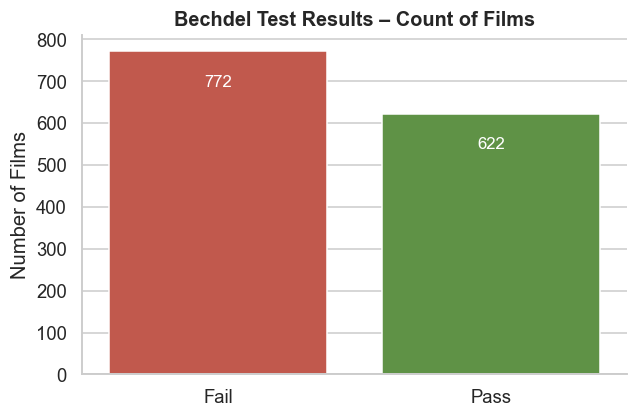

In [35]:
# =============================================================================
# BECHDEL TEST RESULTS — SIMPLE COUNTPROFILE VISUALIZATION
# =============================================================================

# Step 1: Create compact figure (6x4 inches = perfect for slides/reports)
fig, ax = plt.subplots(figsize=(6, 4))

# Step 2: Create bar chart showing count of films by Bechdel test result
# data=bechdel: Our dataset with "test" column ("Fail"/"Pass")
# x="test": Bars grouped by test result
# hue="test": Color bars by test result (same grouping)
sns.countplot(
    data=bechdel,                    # Dataset containing Bechdel results
    x="test",                       # X-axis: "Fail" vs "Pass" categories
    hue="test",                     # Color-code by same "test" column
    palette={"Fail": FAIL_COLOR, "Pass": PASS_COLOR},  # Custom colors (defined earlier)
    order=["Fail", "Pass"],         # Force Fail→Pass order (not alphabetical)
    legend=False,                   # Hide redundant legend (colors self-explanatory)
    ax=ax                           # Plot on our axis
)

# Step 3: ADD COUNTS DIRECTLY ON BARS (most readable feature!)
# Loop through each bar container (one per category)
for container in ax.containers:
    # Label each bar with exact count ("%d" = integer format)
    # padding=-25: Inside bar (negative = toward center)
    # color="white": High contrast against colored bars
    ax.bar_label(
        container, 
        fmt="%d",          # Format: whole numbers only
        padding=-25,       # Position inside bar
        fontsize=11, 
        color="white"
    )

# Step 4: Professional formatting
ax.set_title("Bechdel Test Results – Count of Films", 
             fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Films")     # Y-axis label
ax.set_xlabel("")                    # Remove X label (redundant with xticklabels)
ax.set_xticklabels(["Fail", "Pass"]) # Clean, bold category labels

# Step 5: Modern styling
sns.despine()        # Remove top/right spines (clean look)
plt.tight_layout()   # Perfect spacing
plt.show()


## 3. Exploratory Data Analysis (EDA)

### 3.1 Movie Scores – Metacritic vs IMDB Rating



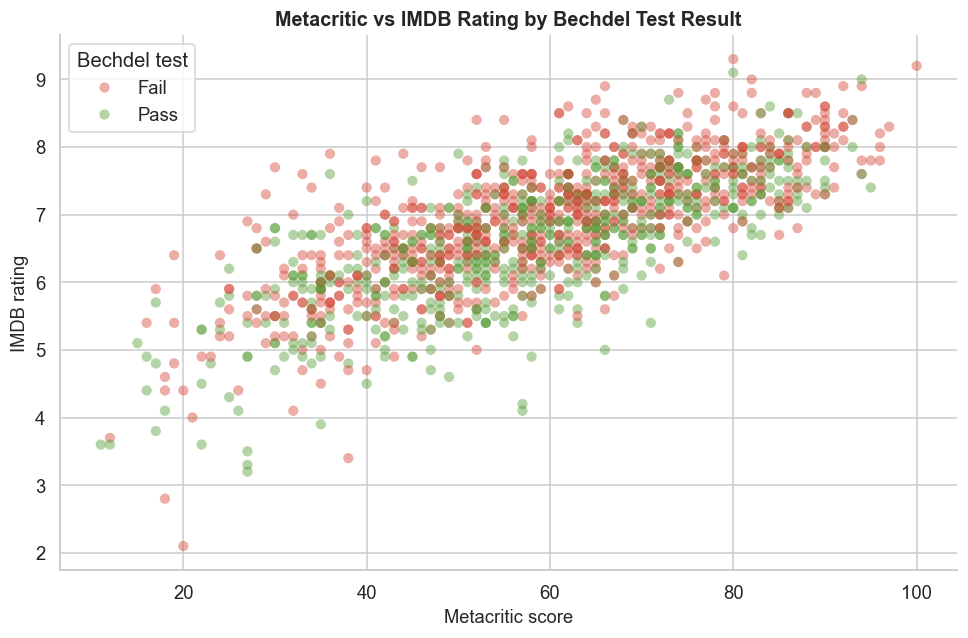

In [ ]:
# =============================================================================
# SCATTERPLOT: METACRITIC vs IMDB BY BECHDEL RESULT
# =============================================================================

# Step 1: Create figure sized for publication (9x6 = good scatterplot proportions)
fig, ax = plt.subplots(figsize=(9, 6))

# Step 2: Create scatterplot showing relationship between critic vs audience scores
sns.scatterplot(
    data=bechdel,                           # Dataset with scores + Bechdel results
    x="metascore",                         # X-axis: Professional critic scores (Metacritic)
    y="imdb_rating",                       # Y-axis: Audience ratings (IMDB)
    hue="test",                            # Color dots by Bechdel result (Fail/Pass)
    palette={"Fail": FAIL_COLOR, "Pass": PASS_COLOR},  # Custom intuitive colors
    alpha=0.45,                            # 45% transparency (see overlaps)
    s=45,                                  # Dot size (not too big/small)
    edgecolor="none",                      # No black outlines (clean modern look)
    ax=ax,                                 # Target axis
    legend=True                            # Show legend (essential for hue)
)

# Step 3: Professional axis labels and title
ax.set_xlabel("Metacritic score", fontsize=12)                    # Critics (0-100)
ax.set_ylabel("IMDB rating", fontsize=12)                         # Audience (0-10)
ax.set_title("Metacritic vs IMDB Rating by Bechdel Test Result", 
             fontsize=13, fontweight="bold")

# Step 4: Format legend
ax.legend(title="Bechdel test")  # Clear title explaining colors

# Step 5: Modern styling
sns.despine()        # Remove top/right spines
plt.tight_layout()   # Optimal spacing
plt.show()


### 3.2 Feature Distributions – Any Outliers?

Box plots for `budget_2013`, `domgross_2013`, `intgross_2013`, `imdb_rating`, and `metascore`,
split by Bechdel test result. Replicates the R `facet_wrap` + `geom_boxplot`.


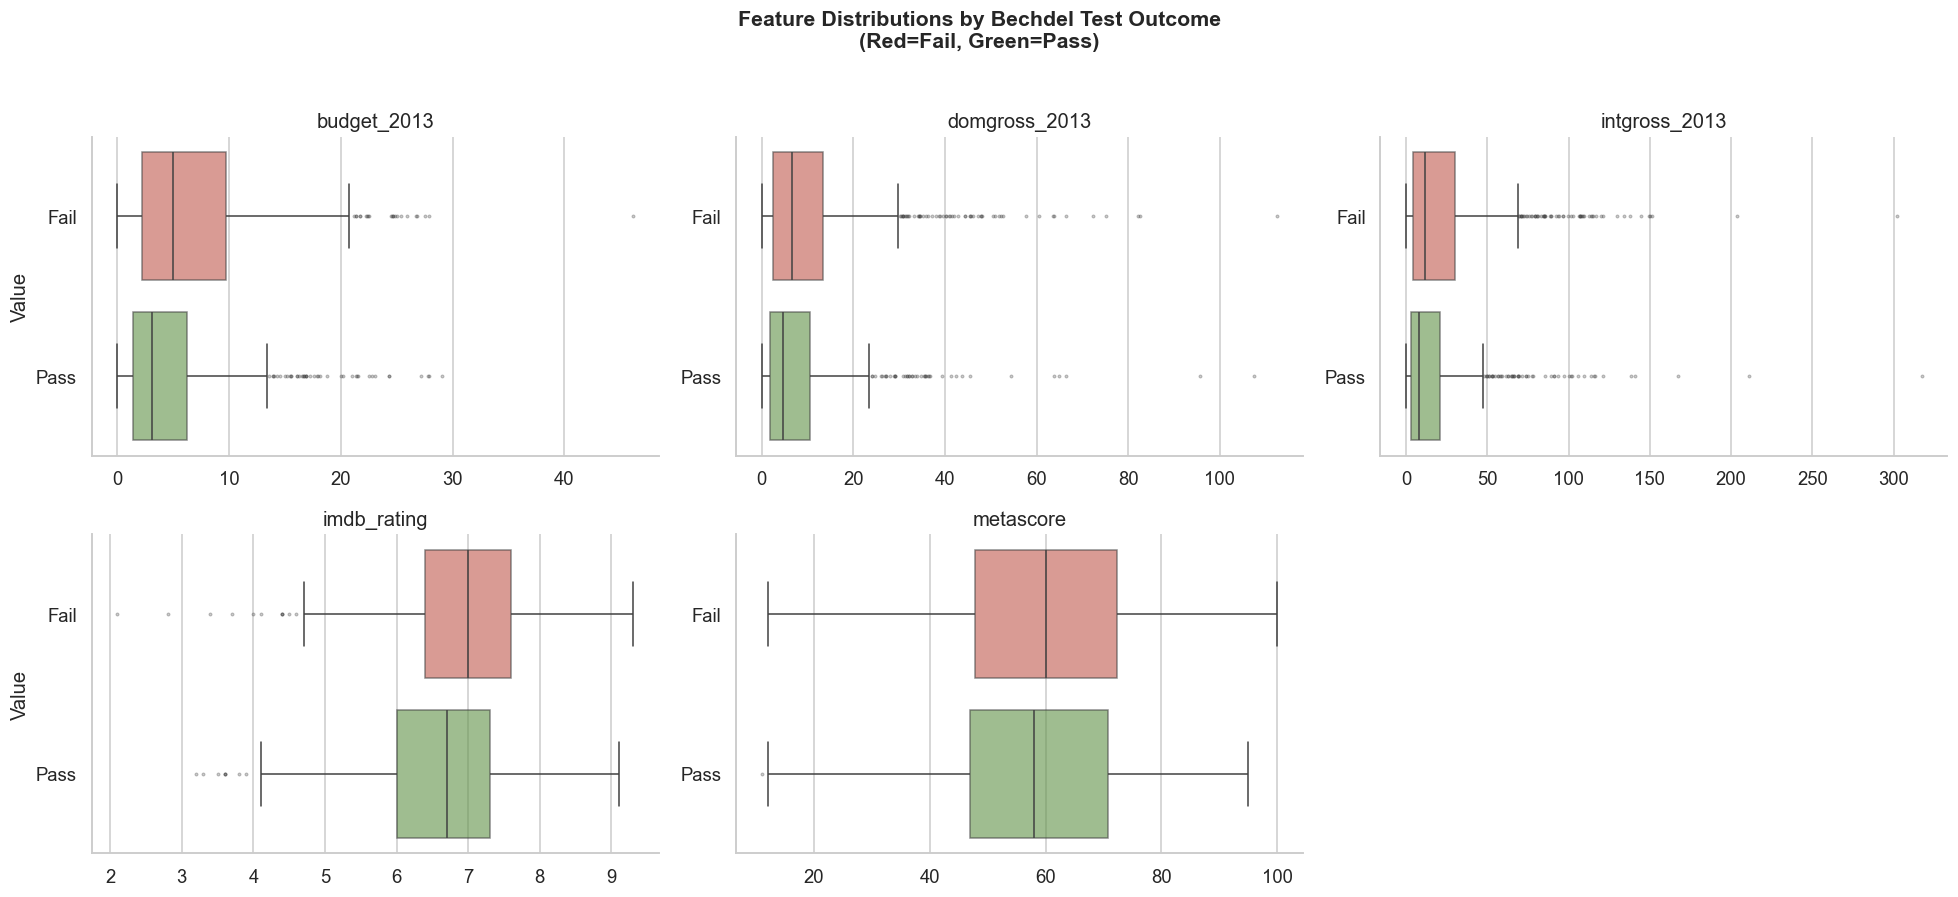

In [7]:
# =============================================================================
# BOXPLOT FACET GRID: ALL FEATURES BY BECHDEL RESULT
# =============================================================================

# Step 1: Define features to compare between Fail vs Pass movies
features_to_plot = [
    "budget_2013",     # Budget (inflation-adjusted)
    "domgross_2013",   # Domestic gross
    "intgross_2013",   # International gross  
    "imdb_rating",     # Audience score
    "metascore"        # Critic score
]

# Step 2: Convert wide data → LONG FORM (required for catplot facets)
# pd.melt "unpivots" multiple feature columns into single "feature" + "value" columns
bechdel_long = pd.melt(
    bechdel[features_to_plot + ["test"]].dropna(subset=features_to_plot),  # Drop rows missing any feature
    id_vars="test",             # Keep "test" column unchanged (groups rows)
    var_name="feature",         # New column: feature names ("budget_2013", etc.)
    value_name="value"          # New column: actual values
)
# Result: 1 row per movie-feature → perfect for faceting

# Step 3: Create 5-panel boxplot grid (Fail vs Pass for each feature)
g = sns.catplot(
    data=bechdel_long,           # Long-form data
    kind="box",                  # Box-and-whisker plots
    y="test",                    # Y-axis: Fail vs Pass (vertical boxes)
    x="value",                   # X-axis: feature values (horizontal spread)
    col="feature",               # Create 1 subplot per feature
    col_wrap=3,                  # 3 columns → 2 rows (5 total = 3+2)
    sharex=False,                # Independent X scales per feature (different units)
    sharey=False,                # Independent Y scales (Fail/Pass consistent)
    palette={"Fail": FAIL_COLOR, "Pass": PASS_COLOR},  # Color-code boxes
    height=4, aspect=1.5,        # Panel size (tall, wide enough for boxes)
    boxprops=dict(alpha=0.6),    # Semi-transparent boxes (see density)
    flierprops=dict(             # Customize outlier dots
        marker=".",              # Small dots
        markersize=3, 
        alpha=0.4
    ),
)

# Step 4: Customize subplot titles and labels
g.set_titles("{col_name}")           # Each panel titled with feature name
g.set_axis_labels("", "Value")       # Clean global labels

# Step 5: Master title for entire figure
g.fig.suptitle("Feature Distributions by Bechdel Test Outcome\n(Red=Fail, Green=Pass)", 
               fontsize=14, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()


### 3.3 Scatterplot Correlation Matrix

Replicates the `GGally::ggpairs` output. 

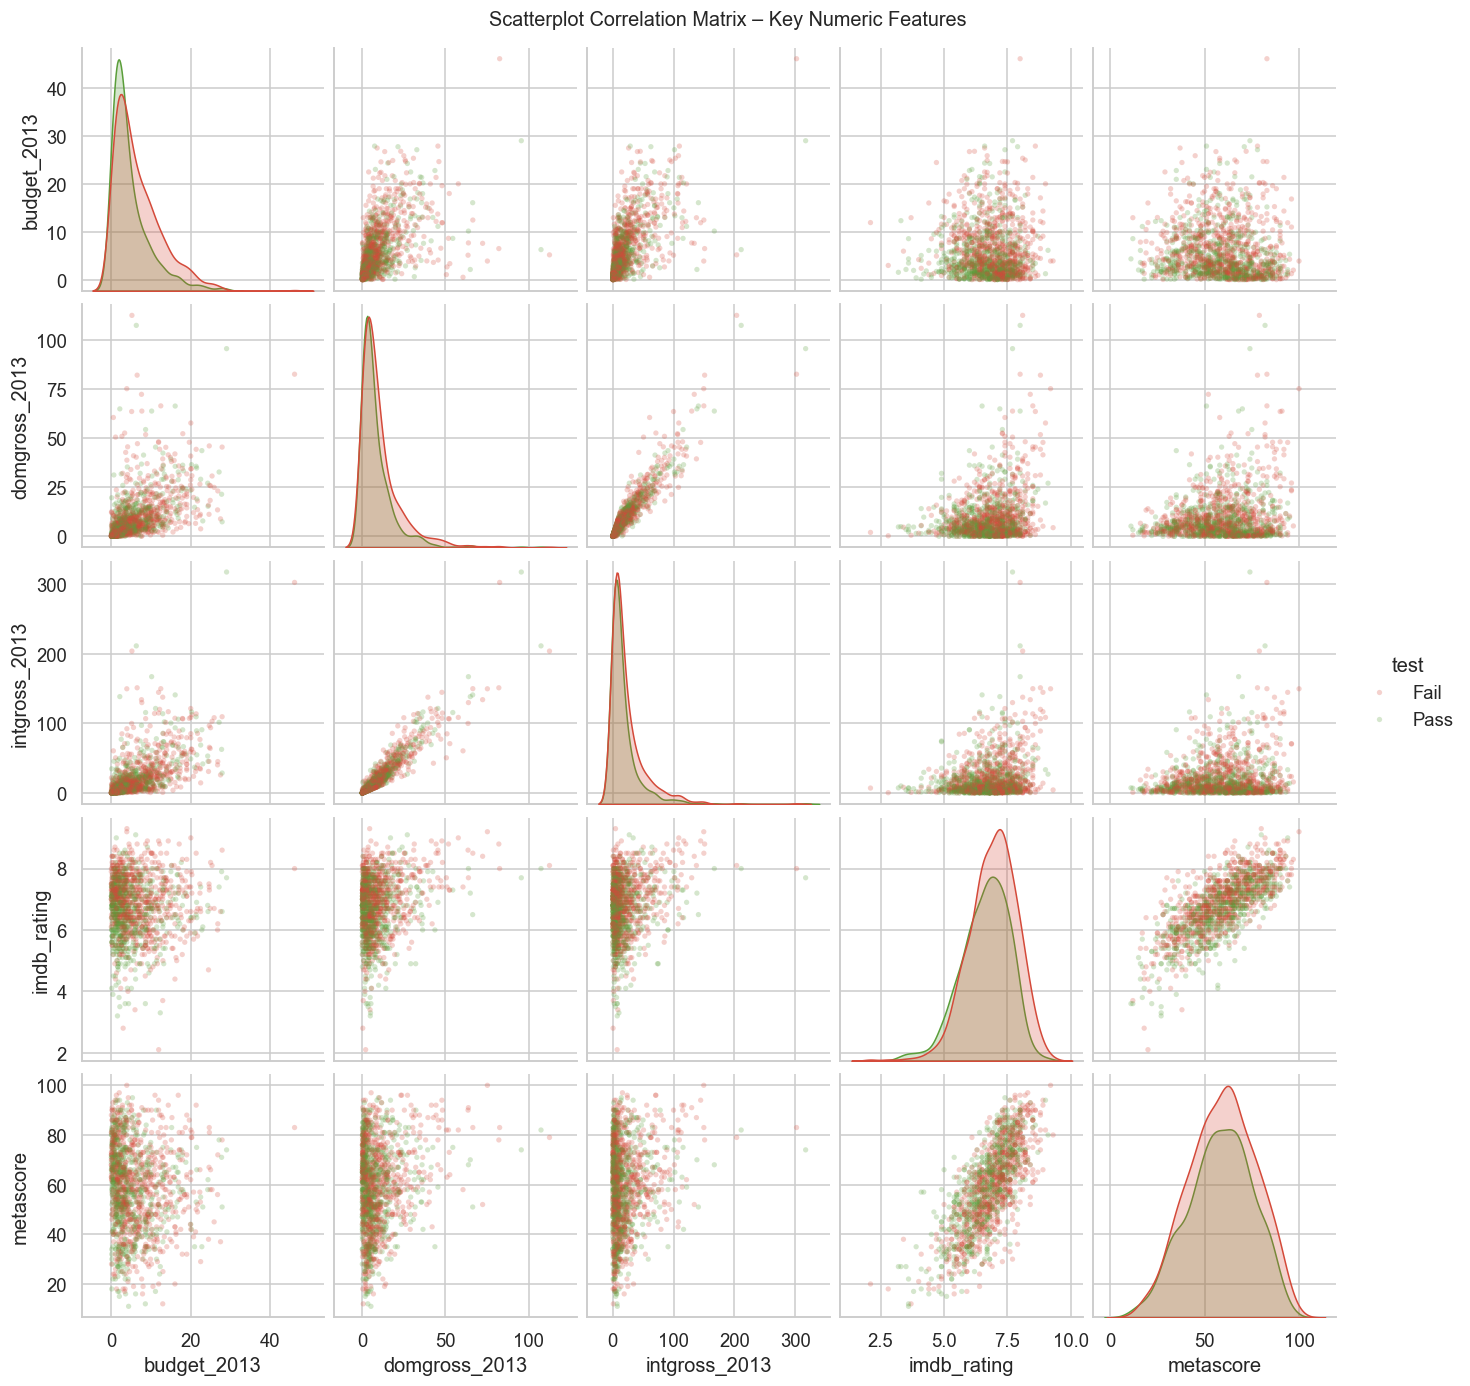

In [ ]:
# =============================================================================
# PAIRPLOT: CORRELATION MATRIX OF KEY FEATURES BY BECHDEL RESULT
# =============================================================================

# Step 1: Select numeric features for pairwise scatterplots + Bechdel grouping
pair_cols = [
    "budget_2013",     # Budget (inflation-adjusted $M)
    "domgross_2013",   # US box office ($M)
    "intgross_2013",   # International box office ($M)
    "imdb_rating",     # Audience score (0-10)
    "metascore"        # Critic score (0-100)
]

# Step 2: Prepare clean dataset (drop missing values across ALL selected columns)
plot_df = bechdel[pair_cols + ["test"]].dropna()
# Result: 5×5 correlation matrix + color-coded by Fail/Pass

# Step 3: Create comprehensive pairplot (GGally::ggpairs equivalent)
# Generates: 5×5 grid = 25 subplots (diagonal=density, off-diagonal=scatter)
pg = sns.pairplot(
    plot_df,                             # Clean dataset
    hue="test",                          # Color-code EVERY point by Bechdel result
    palette={"Fail": FAIL_COLOR, "Pass": PASS_COLOR},  # Red=Fail, Green=Pass
    plot_kws=dict(                       # Customize ALL scatterplots
        alpha=0.25,                      # Heavy transparency (critical for dense plots)
        s=12,                            # Small dots (5×5=25 plots → can't be huge)
        edgecolor="none"                 # Clean dots, no black outlines
    ),
    diag_kind="kde",                     # Diagonal: Density curves (not histograms)
)

# Step 4: Master title for entire 5×5 grid
pg.figure.suptitle("Scatterplot Correlation Matrix – Key Numeric Features", 
                   y=1.01, fontsize=13)

plt.show()



Spearman correlation matrix:
               budget_2013  domgross_2013  intgross_2013  imdb_rating  \
budget_2013          1.000          0.669          0.714       -0.053   
domgross_2013        0.669          1.000          0.952        0.144   
intgross_2013        0.714          0.952          1.000        0.156   
imdb_rating         -0.053          0.144          0.156        1.000   
metascore           -0.152          0.066          0.059        0.738   

               metascore  
budget_2013       -0.152  
domgross_2013      0.066  
intgross_2013      0.059  
imdb_rating        0.738  
metascore          1.000  


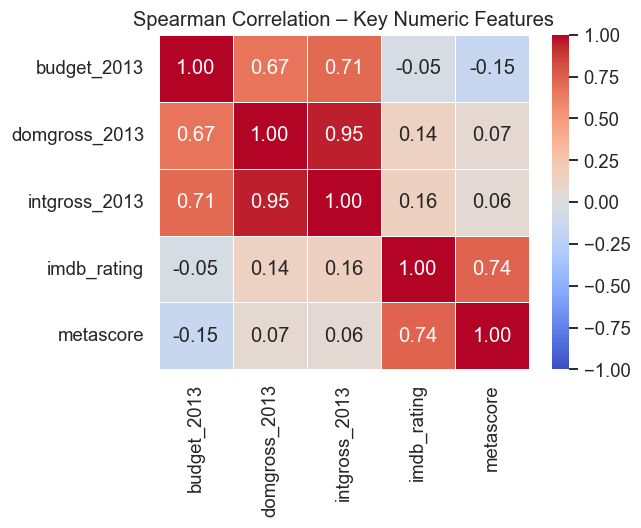

In [9]:
# =============================================================================
# SPEARMAN CORRELATION MATRIX — ROBUST TO NON-NORMAL DATA
# =============================================================================

# Step 1: Calculate Spearman rank correlations (not Pearson!)
# Why Spearman? Ranks data → robust to outliers/skewed distributions
# Perfect for box office $ (heavy right skew) and ratings (bounded)
print("\nSpearman correlation matrix:")
corr = plot_df[pair_cols].corr(method="spearman").round(3)
print(corr)  # Console output for exact values

# Step 2: Visualize correlations as publication-ready heatmap
fig, ax = plt.subplots(figsize=(6, 5))  # Compact square for 5×5 matrix

sns.heatmap(
    corr,                    # Spearman correlation matrix
    annot=True,              # Show numbers INSIDE each cell
    fmt=".2f",               # 2 decimal places (e.g., 0.72)
    cmap="coolwarm",         # Blue=negative, White=0, Red=positive
    vmin=-1, vmax=1,         # Fixed color scale (-1 to +1)
    linewidths=0.5,          # White gridlines between cells
    ax=ax                    # Target axis
)

ax.set_title("Spearman Correlation – Key Numeric Features", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


**Discussion (write your paragraph here):**

*Describe what you see in the pair plots: which features are correlated with each other,
whether Pass/Fail groups appear visually separable, and any notable patterns or outliers.*


### 3.4 Categorical Variables – Genre and Rating



In [10]:
# =============================================================================
# GENRE BREAKDOWN: PASS/FAIL PROPORTIONS BY GENRE
# =============================================================================

# Step 1: Create contingency table (genre × test result → count)
# groupby(["genre", "test"]).size() = crosstab equivalent
genre_tbl = (
    bechdel.groupby(["genre", "test"])      # Group by genre AND test result
    .size()                                 # Count movies per combination
    .rename("n")                            # Rename count column to "n"
    .reset_index()                          # Convert to tidy DataFrame
)

# Step 2: Calculate PASS proportion WITHIN each genre
# Key insight: What % of Action movies pass? What % of Drama pass?
genre_tbl["prop"] = genre_tbl.groupby("genre")["n"].transform(
    lambda x: x / x.sum()
)

# Step 3: Display sorted results (genre → test order)
print("Pass/Fail proportions by Genre:")
print(genre_tbl.sort_values(["genre", "test"]).to_string(index=False))


Pass/Fail proportions by Genre:
      genre test   n     prop
     Action Fail 260 0.706522
     Action Pass 108 0.293478
  Adventure Fail  52 0.559140
  Adventure Pass  41 0.440860
  Animation Fail  63 0.677419
  Animation Pass  30 0.322581
  Biography Fail  36 0.553846
  Biography Pass  29 0.446154
     Comedy Fail 138 0.427245
     Comedy Pass 185 0.572755
      Crime Fail  56 0.622222
      Crime Pass  34 0.377778
Documentary Fail   3 1.000000
      Drama Fail 121 0.472656
      Drama Pass 135 0.527344
    Fantasy Fail   4 0.666667
    Fantasy Pass   2 0.333333
     Horror Fail  25 0.328947
     Horror Pass  51 0.671053
    Musical Pass   1 1.000000
    Mystery Fail   9 0.750000
    Mystery Pass   3 0.250000
     Sci-Fi Fail   5 1.000000
   Thriller Pass   3 1.000000


In [11]:
# =============================================================================
# MPAA RATING BREAKDOWN: PASS/FAIL PROPORTIONS BY RATING
# =============================================================================

# Step 1: Create contingency table (MPAA rating × test result → counts)
# Identical pattern to genre analysis, just different grouping variable
rated_tbl = (
    bechdel.groupby(["rated", "test"])     # Group by MPAA rating AND Bechdel result
    .size()                                # Count movies per rating-test combo
    .rename("n")                           # Rename to "n" (count)
    .reset_index()                         # Convert MultiIndex → tidy DataFrame
)

# Step 2: Calculate PASS proportion WITHIN each MPAA rating
# Question: What % of PG-13 movies pass Bechdel? R? PG?
rated_tbl["prop"] = rated_tbl.groupby("rated")["n"].transform(
    lambda x: x / x.sum()  # For each rating: prop = count / total_for_that_rating
)

# Step 3: Display results sorted by rating → test (PG, PG-13, R, etc.)
print("Pass/Fail proportions by Rated (MPAA):")
print(rated_tbl.sort_values(["rated", "test"]).to_string(index=False))


Pass/Fail proportions by Rated (MPAA):
rated test   n     prop
    G Fail  16 0.615385
    G Pass  10 0.384615
NC-17 Fail   5 0.833333
NC-17 Pass   1 0.166667
   PG Fail 115 0.560976
   PG Pass  90 0.439024
PG-13 Fail 283 0.528972
PG-13 Pass 252 0.471028
    R Fail 353 0.567524
    R Pass 269 0.432476


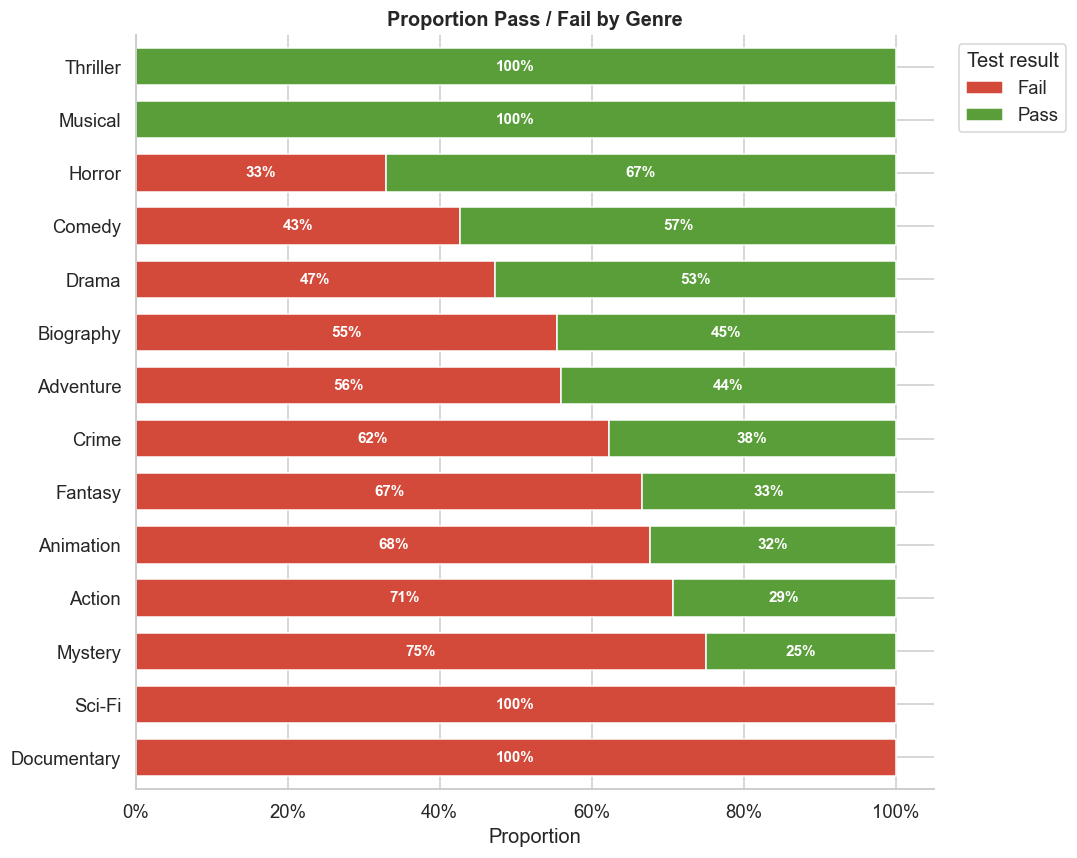

In [36]:
# =============================================================================
# STACKED BAR CHART: PASS/FAIL PROPORTIONS BY GENRE
# =============================================================================

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick  # For percentage formatting

# Step 1: Convert long tidy data → WIDE pivot for stacked bars
# Each row=genre, columns=Fail/Pass proportions (0-1)
pivot_genre = genre_tbl.pivot(
    index="genre",           # Rows: one per genre
    columns="test",          # Columns: Fail, Pass
    values="prop"            # Cell values: proportions from earlier calculation
).fillna(0)                  # Missing combos → 0

# Step 2: Sort so BEST genres (highest Pass %) appear at TOP
pivot_genre = pivot_genre.sort_values("Pass", ascending=True)

# Step 3: Create stacked horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 8))  # Wide + tall for many genres

pivot_genre[["Fail", "Pass"]].plot(  # Select only Fail/Pass columns
    kind="barh",                    # Horizontal bars (genre names fit better)
    stacked=True,                   # Stack Fail+Pass = 100% per genre
    color=[FAIL_COLOR, PASS_COLOR], # Red=Fail, Green=Pass
    edgecolor="white", width=0.7,   # White borders, 70% bar width
    ax=ax
)

# =============================================================================
# FORMATTING: MAKE IT PUBLICATION-READY
# =============================================================================

# 1. X-AXIS → PERCENTAGES (0.4 → 40%)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# 2. ADD % VALUES INSIDE EACH STACKED SEGMENT
for container in ax.containers:  # One container per color (Fail, then Pass)
    # Convert 0-1 → % and skip tiny segments (<2% = unreadable)
    labels = [f"{v * 100:.0f}%" if v > 0.02 else "" for v in container.datavalues]
    
    ax.bar_label(
        container,
        labels=labels,           # Custom % labels
        label_type="center",     # Center in each stacked section
        color="white",           # High contrast
        fontsize=10,
        fontweight="bold"
    )

# 3. Final polish
ax.set_title("Proportion Pass / Fail by Genre", fontsize=13, fontweight="bold")
ax.set_xlabel("Proportion")
ax.set_ylabel("")  # Genre names already on Y-axis

# Legend OUTSIDE plot (prevents overlap with bar labels)
ax.legend(title="Test result", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.despine()        # Clean edges
plt.tight_layout()
plt.show()


**Discussion (write your paragraph here):**

*Which genres have the highest pass rates? Are there genres with very few films that make proportions unreliable?
Which MPAA ratings pass more often? Do you see any meaningful patterns?*


## 4. Split the Data



In [37]:
# =============================================================================
# DATA PREPARATION: TRAIN/TEST SPLIT FOR MODELING
# =============================================================================

# Step 1: IDENTIFY FEATURE TYPES 
numeric_cols = [     # Continuous variables (impute + scale later)
    "budget_2013",     # Budget in 2013 dollars ($M)
    "domgross_2013",   # US box office ($M)
    "intgross_2013",   # International box office ($M)
    "imdb_rating",     # Audience score (0-10)
    "metascore"        # Critic score (0-100)
]

categorical_cols = [  # Discrete categories (one-hot encode later)
    "genre",           # Action, Drama, Comedy, etc.
    "rated"            # PG-13, R, PG, etc. (MPAA rating)
]

# Step 2: Define complete feature set + target
feature_cols = numeric_cols + categorical_cols  # All predictors
target_col = "test"                            # Outcome: "Fail"/"Pass"

# Step 3: Create clean modeling dataset
# Drop rows missing TARGET (can't predict missing outcomes)
# Keep rows with missing features (we'll impute them)
bechdel_model = bechdel[feature_cols + [target_col]].copy()

# Step 4: Separate features (X) from target (y)
X = bechdel_model[feature_cols]    # 7 predictor columns
y = bechdel_model[target_col]      # Single outcome column

# Step 5: 80/20 TRAIN/TEST SPLIT (industry standard)
# stratify=y: Ensures SAME % Fail/Pass in train AND test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                           # Features + target
    test_size=0.20,                 # 20% for testing (unseen data)
    random_state=123,               # Reproducible split (like set.seed(123))
    stratify=y                      # Maintain class balance (critical for imbalanced data!)
)

# Step 6: Verify split worked correctly
print(f"Training set : {X_train.shape[0]:,} rows")   # ~80% of data
print(f"Test set     : {X_test.shape[0]:,} rows")    # ~20% of data
print(f"Train balance: {y_train.value_counts(normalize=True).round(3)}")  # Should match full data


Training set : 1,115 rows
Test set     : 279 rows
Train balance: test
Fail    0.553
Pass    0.447
Name: proportion, dtype: float64


In [38]:
# Check class proportions in each split – replicates the R check
print("Class proportions in the TRAINING set:")
print(y_train.value_counts(normalize=True).round(3).to_frame("proportion"))

print("\nClass proportions in the TEST set:")
print(y_test.value_counts(normalize=True).round(3).to_frame("proportion"))


Class proportions in the TRAINING set:
      proportion
test            
Fail       0.553
Pass       0.447

Class proportions in the TEST set:
      proportion
test            
Fail       0.556
Pass       0.444


## 5. Feature Engineering with Recipes (sklearn Pipelines)

### 5.1 Collapse Rare Genre Levels

We identify genres representing < 3% of the training set and lump them into `"Other"`.


Genres below 3% threshold → will be collapsed to 'Other':
['Documentary', 'Fantasy', 'Musical', 'Mystery', 'Sci-Fi', 'Thriller']


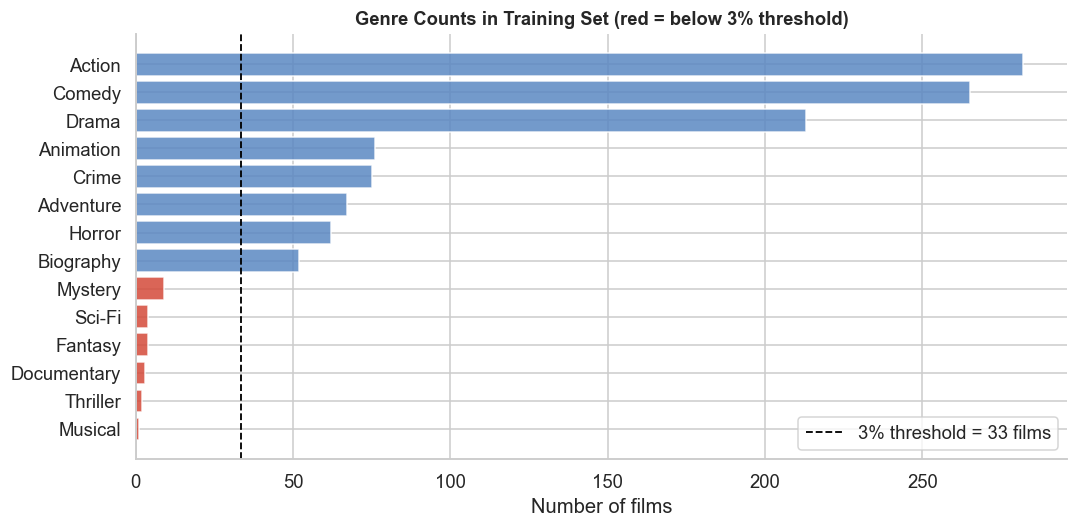

In [39]:
# =============================================================================
# RARE GENRE HANDLING — COLLAPSE TO "OTHER" (AVOIDS MODEL INSTABILITY)
# =============================================================================

# Step 1: Count genre frequency IN TRAINING SET ONLY (test set irrelevant for preprocessing)
genre_counts = (
    y_train.to_frame()           # Target + index
    .join(X_train["genre"])      # Add genre column
    .groupby("genre")            # Group by genre name
    .size()                      # Count movies per genre
)

# Step 2: Calculate % share of each genre
genre_pct = genre_counts / genre_counts.sum()  # Divide by TOTAL training movies

# Step 3: Identify rare genres (<3% of training data)
# Why 3%? Too few examples → unstable model coefficients
threshold = 0.03  # 3% minimum viable sample size
rare_genres = genre_pct[genre_pct < threshold].index.tolist()

print(f"Genres below {threshold:.0%} threshold → will be collapsed to 'Other':")
print(rare_genres)

# Step 4: Visualize decision with threshold line
fig, ax = plt.subplots(figsize=(10, 5))

# Sort genres by count (smallest first)
sorted_genres = genre_counts.sort_values()

# Color-code: Red=rare (collapse), Blue=keep
colors = [
    FAIL_COLOR if g in rare_genres else "#5b88c2" 
    for g in sorted_genres.index
]

# Horizontal bar chart
ax.barh(
    sorted_genres.index,           # Genre names (Y-axis)
    sorted_genres.values,          # Counts (X-axis)
    color=colors,                  # Red vs blue
    edgecolor="white", alpha=0.85
)

# Add threshold line (visual justification)
ax.axvline(
    len(y_train) * threshold,      # 3% of total training movies
    color="black", linestyle="--", linewidth=1.2,
    label=f"3% threshold = {int(len(y_train)*threshold)} films"
)

# Formatting
ax.set_title("Genre Counts in Training Set (red = below 3% threshold)", 
             fontsize=12, fontweight="bold")
ax.set_xlabel("Number of films")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()


### 5.2 Full Preprocessing Pipeline




In [17]:
# =============================================================================
# PREPROCESSING PIPELINE — Production-ready feature engineering
# =============================================================================

from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_selection import VarianceThreshold

# ────────────────────────────────────────────────────────────────────────────
# CUSTOM PREPROCESSOR: Collapse rare genres to "Other"
# ────────────────────────────────────────────────────────────────────────────
def collapse_rare_genres(X_df, rare):
    """
    Replace rare genres (<3% threshold) with 'Other' category.
    Prevents model instability from genres with 1-2 movies only.
    """
    out = X_df.copy()
    out["genre"] = out["genre"].apply(lambda g: "Other" if g in rare else g)
    return out

# Wrap custom function as sklearn-compatible transformer
# rare_genres computed from training data (no leakage!)
genre_collaper = FunctionTransformer(
    # Lambda receives numpy array → converts to DataFrame → processes → extracts features
    lambda X: collapse_rare_genres(
        pd.DataFrame(X, columns=feature_cols),  # Reconstruct DataFrame
        rare_genres                             # Training-derived rare list
    )[feature_cols],  # Return only feature columns (no target)
    validate=False    # Skip input validation (faster)
)

# ────────────────────────────────────────────────────────────────────────────
# NUMERIC PIPELINE: Impute → Remove zero-variance → Scale
# ────────────────────────────────────────────────────────────────────────────
num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),     # Fill missing with median
    ("zv", VarianceThreshold(threshold=0)),           # Drop constant columns
    ("scale", StandardScaler()),                      # Mean=0, SD=1 (required for many models)
])

# ────────────────────────────────────────────────────────────────────────────
# CATEGORICAL PIPELINE: Impute → One-hot encode
# ────────────────────────────────────────────────────────────────────────────
cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),  # Most common category
    ("ohe", OneHotEncoder(                               # Convert categories → 0/1 columns
        handle_unknown="ignore",                          # New test categories → 0s
        sparse_output=False,                              # Dense array (faster)
        drop="first"                                      # Remove 1st category (no multicollinearity)
    )),
])

# ────────────────────────────────────────────────────────────────────────────
# MASTER PREPROCESSOR: Parallel numeric + categorical streams
# ────────────────────────────────────────────────────────────────────────────
preprocessor = ColumnTransformer([
    ("num", num_pipe, numeric_cols),    # Apply num_pipe to numeric_cols only
    ("cat", cat_pipe, categorical_cols),# Apply cat_pipe to categorical_cols only
])

# Step 4: SANITY CHECK — Test pipeline works!
X_tr_sample = preprocessor.fit_transform(X_train)
print(f"Transformed training shape: {X_tr_sample.shape}")
print(f"  → {len(numeric_cols)} numeric + expanded categories = {X_tr_sample.shape[1]} features")
print("[SUCCESS] Preprocessing pipeline ready.")


Transformed training shape: (1115, 22)
[SUCCESS] Preprocessing pipeline ready.


## 6. Helper Functions (Confusion Matrix & ROC)



In [18]:
# =============================================================================
# HELPER FUNCTIONS & SHARED COLOUR PALETTE — used consistently across ALL plots in this notebook
# =============================================================================

# Defining colours once here avoids inconsistency between plots and makes it
# easy to update the entire notebook's colour scheme in one place.
# Run this cell once; all subsequent cells reference these constants.

CLR_TP = '#2ecc71'   # True Positive  → green  
CLR_TN = '#3498db'   # True Negative  → blue   
CLR_FP = '#e74c3c'   # False Positive → red    
CLR_FN = '#f39c12'   # False Negative → orange (wrong:  model missed a case — most dangerous)
CLR_CURVE  = '#8e44ad'  # ROC / S-curve line → purple
CLR_DARK   = '#2c3e50'  # S-curve model line / perfect classifier → dark navy

# Dictionaries for easy lookup by outcome label string ('TP', 'TN', 'FP', 'FN')
OUTCOME_COLOURS = {'TP': CLR_TP, 'TN': CLR_TN, 'FP': CLR_FP, 'FN': CLR_FN}
OUTCOME_MARKERS = {'TP': 'o',    'TN': 'o',    'FP': 'X',    'FN': 'X'}  # X marks wrong predictions


def get_outcomes(y_true, y_pred):
    """Return per-observation outcome labels: TP / TN / FP / FN."""
    import numpy as np
    result = []
    for yt, yp in zip(y_true, y_pred):
        if   yp == 1 and yt == 1: result.append('TP')
        elif yp == 0 and yt == 0: result.append('TN')
        elif yp == 1 and yt == 0: result.append('FP')
        else:                     result.append('FN')
    return np.array(result)

def plot_confusion_matrix(ax, y_true, y_pred, title, y_proba=None):
    from sklearn.metrics import confusion_matrix, roc_auc_score


    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP_v = cm.ravel()

    # Rows = Actual, Cols = Predicted
    # Top-left=TP, Top-right=FN, Bottom-left=FP, Bottom-right=TN
    cell_colours = [[CLR_TP, CLR_FN], [CLR_FP, CLR_TN]]
    cell_labels  = [[f'TP\n{TP_v}', f'FN\n{FN}'], [f'FP\n{FP}', f'TN\n{TN}']]

    ax.set_xlim(0, 2); ax.set_ylim(0, 2)
    for r in range(2):
        for c in range(2):
            ax.add_patch(plt.Rectangle((c, 1-r), 1, 1,
                         color=cell_colours[r][c], alpha=0.78, zorder=1))
            ax.text(c+0.5, 1-r+0.5, cell_labels[r][c],
                    ha='center', va='center', fontsize=15,
                    fontweight='bold', color='white', zorder=2)

    ax.set_xticks([0.5, 1.5])
    # ax.set_xticklabels(['Predicted: Not Low (0)', 'Predicted: Low (1)'], fontsize=9)
    ax.set_xticklabels(['Predicted: (1)', 'Predicted: (0)'], fontsize=9)

    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(['Actual: (0)', 'Actual: (1)'], fontsize=9)
    # ax.set_yticklabels(['Actual: Low (1)', 'Actual: Not Low (0)'], fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)

    precision = TP_v / (TP_v + FP) if (TP_v + FP) > 0 else 0
    recall    = TP_v / (TP_v + FN) if (TP_v + FN) > 0 else 0
    accuracy  = (TP_v + TN) / len(y_true)

    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        xlabel = (f'Accuracy={accuracy:.2f}  Precision={precision:.2f}  '
                  f'Recall={recall:.2f}  AUC={auc:.3f}')
    else:
        xlabel = (f'Accuracy={accuracy:.2f}  Precision={precision:.2f}  '
                  f'Recall={recall:.2f}')

    ax.set_xlabel(xlabel, fontsize=9, labelpad=8)

def plot_roc_curve(ax, y_true, y_proba, model_name, color=CLR_CURVE):
    """Plot a single ROC curve on an existing axes."""
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f"{model_name}  (AUC={auc:.3f})")
    ax.fill_between(fpr, tpr, alpha=0.06, color=color)
    return auc

print("✅ Shared colour palette and helper functions ready.")





✅ Shared colour palette and helper functions ready.


## 7. Train First Models: `test ~ metascore + imdb_rating`

Fit a logistic regression and decision tree using **only** `metascore + imdb_rating`.


In [24]:
# =============================================================================
# LABEL ENCODING + SIMPLE 2-FEATURE PREPROCESSOR
# =============================================================================

# ────────────────────────────────────────────────────────────────────────────
# TARGET ENCODING: Convert "Fail"/"Pass" → 0/1 numeric labels
# ────────────────────────────────────────────────────────────────────────────
le = LabelEncoder()  # sklearn's built-in categorical → numeric converter

# Fit on TRAIN labels only → learn mapping from training data
y_train_enc = le.fit_transform(y_train)  # ["Fail","Pass"] → [0,1]
y_test_enc = le.transform(y_test)        # Apply SAME mapping to test (no refit!)

# Verify mapping (Fail=0, Pass=1 due to alphabetical order)
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
# Output: {'Fail': 0, 'Pass': 1}

# ────────────────────────────────────────────────────────────────────────────
# SIMPLE PREPROCESSOR: Just metascore + imdb_rating (teaching example)
# ────────────────────────────────────────────────────────────────────────────
simple_num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),  # Fill missing with median
    ("scale", StandardScaler()),                   # Mean=0, SD=1 (model requirement)
])

# Apply numeric pipeline to ONLY 2 critic/audience score features
simple_pre = ColumnTransformer([
    ("num", simple_num_pipe, ["metascore", "imdb_rating"])  # Select these 2 columns only
])

# 🎯 LabelEncoder: 
# ✅ Fit_transform(train): Learn + convert
# ✅ Transform(test): Apply SAME mapping (no data leakage!)

# 📊 Why encode? All sklearn classifiers expect numeric targets (0/1)

# 🔍 simple_pre shape: 
# Input: 2 features → Output: 2 scaled features
# Perfect for DecisionTree/Logistic teaching demos!

# ✅ Why median + scale? 
# Median: Robust to outliers
# Scale: Trees don't need it, but Logistic/kNN/XGBoost perform better

# Quick preview of pipeline (IPython displays interactive diagram)
simple_num_pipe


Class mapping: {'Fail': np.int64(0), 'Pass': np.int64(1)}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute', ...), ('scale', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fea

### 7.1 Logistic Regression — `test ~ metascore + imdb_rating`

In [25]:
# Step 1: Create a complete pipeline for logistic regression on 2-feature set
# Pipeline chains preprocessing + classifier; ensures consistent transformation
lr_simple_pipe = Pipeline([
    ("pre", simple_pre),                           # Preprocessing step (imputer/scaler/etc)
    ("classifier", LogisticRegression(max_iter=1000, random_state=123))  # Logistic regression classifier
])

# Step 2: Fit pipeline on training data only (prevents data leakage)
# Pipeline automatically applies preprocessing then fits classifier
lr_simple_pipe.fit(X_train[["metascore", "imdb_rating"]], y_train_enc)

# Step 3: Generate predictions on test set using fitted pipeline
# Pipeline applies SAME preprocessing as training + classifier prediction
y_pred_lr_simple = lr_simple_pipe.predict(X_test[["metascore", "imdb_rating"]])

# Step 4: Generate class probabilities for test set (2nd column = positive class probability)
y_proba_lr_simple = lr_simple_pipe.predict_proba(X_test[["metascore", "imdb_rating"]])[:, 1]

# Step 5: Extract model coefficients for interpretation (R broom::tidy equivalent)
# Build coefficient names: intercept + feature names
coef_names = ["Intercept", "metascore", "imdb_rating"]

# Extract intercept and coefficients, concatenate into single array
coef_vals = np.concatenate([
    lr_simple_pipe.named_steps["classifier"].intercept_,     # Intercept (1 value)
    lr_simple_pipe.named_steps["classifier"].coef_[0]        # Coefficients for 2 features
])

# Step 6: Create tidy DataFrame for coefficients (easy to read/print)
tidy_lr = pd.DataFrame({
    "term": coef_names,      # Feature/parameter names
    "estimate": coef_vals    # Coefficient values
})

# Step 7: Display results
print("Logistic Regression Coefficients (simple model):")
print(tidy_lr.to_string(index=False))


Logistic Regression Coefficients (simple model):
       term  estimate
  Intercept -0.221365
  metascore  0.385559
imdb_rating -0.613373


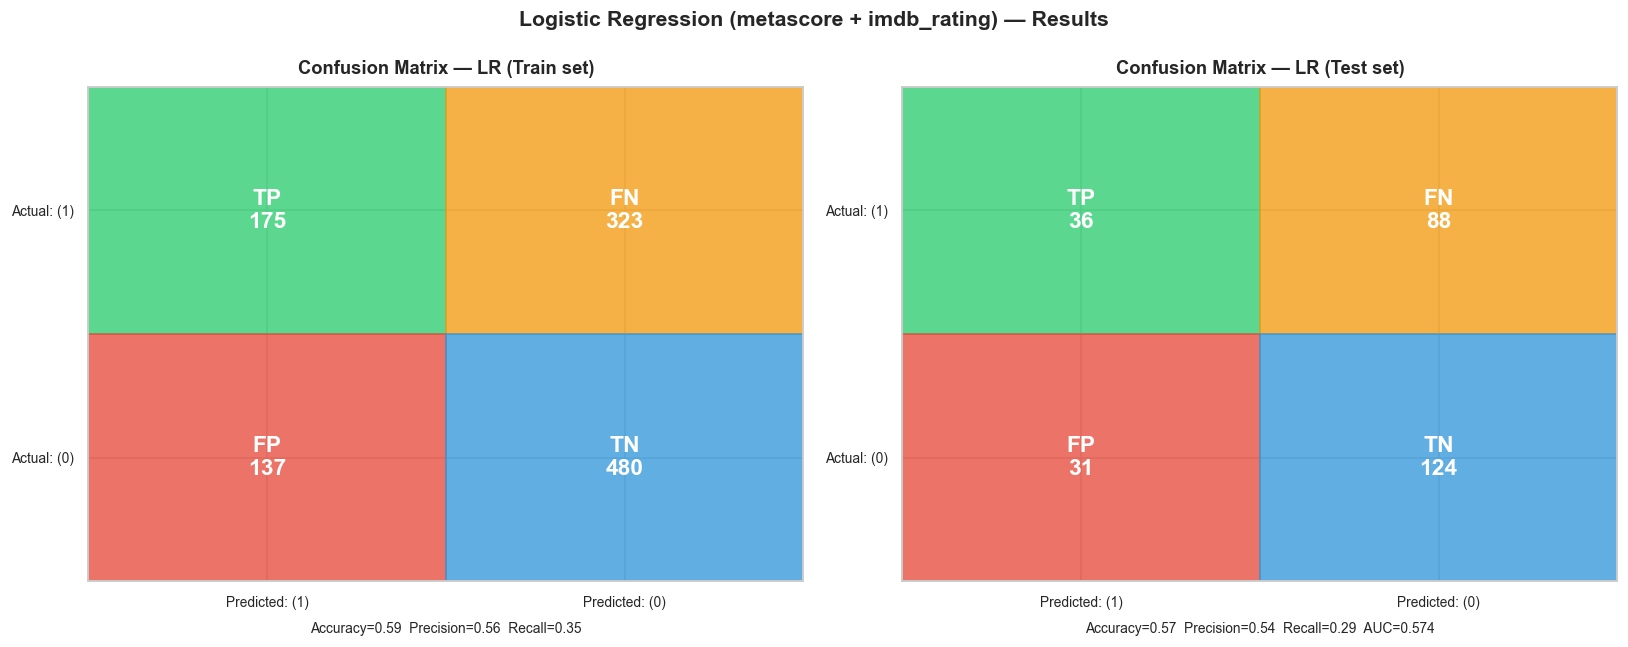

              precision    recall  f1-score   support

        Fail       0.58      0.80      0.68       155
        Pass       0.54      0.29      0.38       124

    accuracy                           0.57       279
   macro avg       0.56      0.55      0.53       279
weighted avg       0.56      0.57      0.54       279



In [26]:
# Confusion matrix — Logistic Regression (simple model, TRAINING set)
y_pred_lr_train = lr_simple_pipe.predict(X_train[["metascore", "imdb_rating"]])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Logistic Regression (metascore + imdb_rating) — Results", fontsize=14, fontweight="bold")

plot_confusion_matrix(axes[0], le.transform(y_train), y_pred_lr_train,
                      "Confusion Matrix — LR (Train set)")

plot_confusion_matrix(axes[1], y_test_enc, y_pred_lr_simple,
                      "Confusion Matrix — LR (Test set)",
                      y_proba=y_proba_lr_simple)
plt.tight_layout()
plt.show()

### 7.2 Decision Tree — `test ~ metascore + imdb_rating`

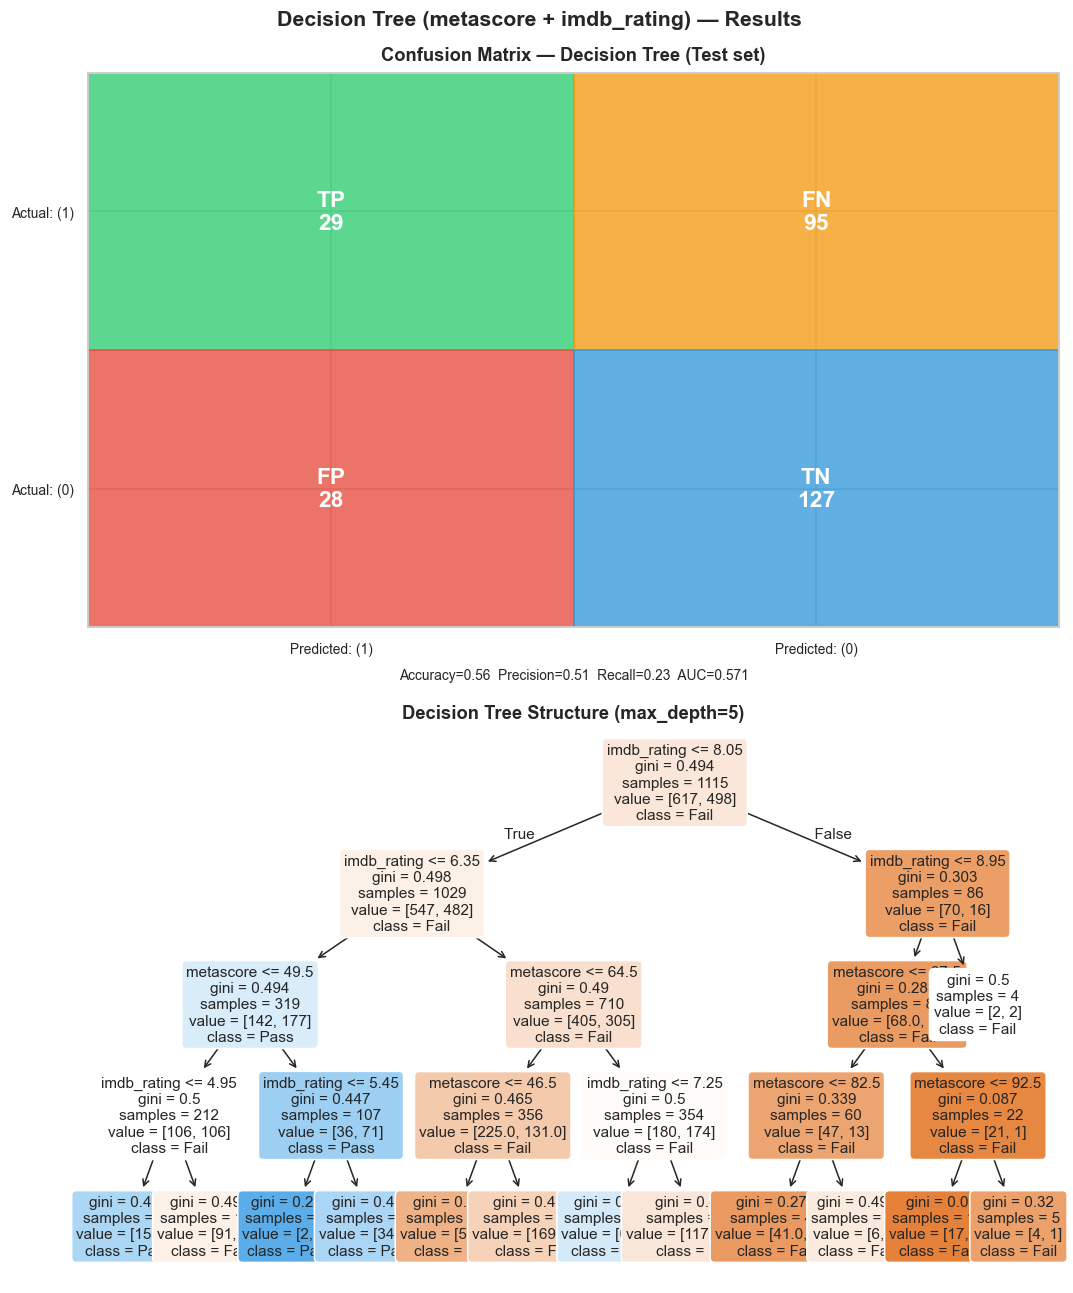

              precision    recall  f1-score   support

        Fail       0.57      0.82      0.67       155
        Pass       0.51      0.23      0.32       124

    accuracy                           0.56       279
   macro avg       0.54      0.53      0.50       279
weighted avg       0.54      0.56      0.52       279



In [27]:
# Step 1: Initialize a simple Decision Tree classifier with constraints to prevent overfitting
# max_depth=4 limits tree complexity; min_samples_split=10 ensures splits need sufficient data
tree_simple = DecisionTreeClassifier(max_depth=4, min_samples_split=10, random_state=123)

# Step 2: Fit the tree on imputed training data
# Use SimpleImputer with median strategy to handle missing values in metascore and imdb_rating
# fit_transform() both fits the imputer on train data AND transforms it (essential to avoid data leakage)
X_train_imputed = SimpleImputer(strategy="median").fit_transform(X_train[["metascore", "imdb_rating"]])
tree_simple.fit(X_train_imputed, y_train_enc)

# Step 3: Create test predictions using SAME imputer fitted on training data (no data leakage!)
# First fit imputer on train data (already done above conceptually), then transform test data only
imputer = SimpleImputer(strategy="median").fit(X_train[["metascore", "imdb_rating"]])
X_test_2f_imp = imputer.transform(X_test[["metascore", "imdb_rating"]])

# Step 4: Generate class predictions and probabilities for test set
y_pred_dt_simple = tree_simple.predict(X_test_2f_imp)
y_proba_dt_simple = tree_simple.predict_proba(X_test_2f_imp)[:, 1]  # [:, 1] extracts probability of positive class

# Step 5: Create subplot layout for visualization (2 rows, 1 column, tall figure)
fig, axes = plt.subplots(2, 1, figsize=(10, 12))
fig.suptitle("Decision Tree (metascore + imdb_rating) — Results", fontsize=14, fontweight="bold")

# Step 6: Plot confusion matrix on top subplot (axes[0])
plot_confusion_matrix(axes[0], y_test_enc, y_pred_dt_simple,
                      "Confusion Matrix — Decision Tree (Test set)",
                      y_proba=y_proba_dt_simple)

# Step 7: Plot decision tree structure on bottom subplot (axes[1])
ax_tree = axes[1]
plot_tree(tree_simple, 
          feature_names=["metascore", "imdb_rating"],
          class_names=le.classes_, 
          filled=True, 
          rounded=True,
          fontsize=10, 
          ax=ax_tree, 
          max_depth=4)
ax_tree.set_title("Decision Tree Structure (max_depth=4)", fontsize=12, fontweight="bold")

# Step 8: Final formatting and display
plt.tight_layout()  # Adjust spacing between subplots
plt.show()




## 8. Cross-Validation — Simple Models



In [28]:
# Step 1: Set up 10-fold stratified cross-validation (equivalent to R's vfold_cv(v=10, strata=test))
# Stratified ensures each fold has same class distribution as full dataset
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

# Step 2: Define multiple scoring metrics to evaluate across different performance aspects
scoring = {
    "roc_auc": "roc_auc",      # Area under ROC curve (good for imbalanced classes)
    "accuracy": "accuracy",    # Overall classification accuracy
    "f1": "f1_weighted"        # F1 score (weighted by class prevalence)
}

# Step 3: Cross-validate Logistic Regression pipeline
# Create fresh pipeline for each model to ensure independence
lr_pipeline = Pipeline([
    ("pre", simple_pre),                           # Preprocessing step
    ("clf", LogisticRegression(max_iter=1000, random_state=123))  # Logistic regression classifier
])

# Run 10-fold CV on training data only (no test set leakage)
lr_cv = cross_validate(
    lr_pipeline,
    X_train[["metascore", "imdb_rating"]], 
    y_train_enc,
    cv=cv10,           # 10-fold stratified splits
    scoring=scoring,   # Multiple metrics
    n_jobs=-1          # Parallel processing across CPU cores
)

# Step 4: Cross-validate Decision Tree pipeline
dt_pipeline = Pipeline([
    ("pre", simple_pre),                                           # Same preprocessing
    ("clf", DecisionTreeClassifier(max_depth=5, random_state=123)) # Decision tree (depth=5)
])

# Run 10-fold CV for decision tree
dt_cv = cross_validate(
    dt_pipeline,
    X_train[["metascore", "imdb_rating"]], 
    y_train_enc,
    cv=cv10,
    scoring=scoring,
    n_jobs=-1
)

# Step 5: Aggregate CV results into tidy summary table (equivalent to collect_metrics())
# Extract mean and std dev for each metric from CV results
metrics_simple = pd.DataFrame({
    "Model":      ["Logistic Regression", "Decision Tree"],
    "Mean AUC":   [lr_cv["test_roc_auc"].mean(),   dt_cv["test_roc_auc"].mean()],
    "Std AUC":    [lr_cv["test_roc_auc"].std(),    dt_cv["test_roc_auc"].std()],
    "Mean Acc":   [lr_cv["test_accuracy"].mean(),  dt_cv["test_accuracy"].mean()],
    "Mean F1":    [lr_cv["test_f1"].mean(),        dt_cv["test_f1"].mean()],
})

# Step 6: Display formatted results
print("Cross-Validation Results (10-fold, simple 2-feature model):")
print(metrics_simple.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


Cross-Validation Results (10-fold, simple 2-feature model):
              Model  Mean AUC  Std AUC  Mean Acc  Mean F1
Logistic Regression    0.6091   0.0574    0.5822   0.5615
      Decision Tree    0.5718   0.0343    0.5570   0.5257


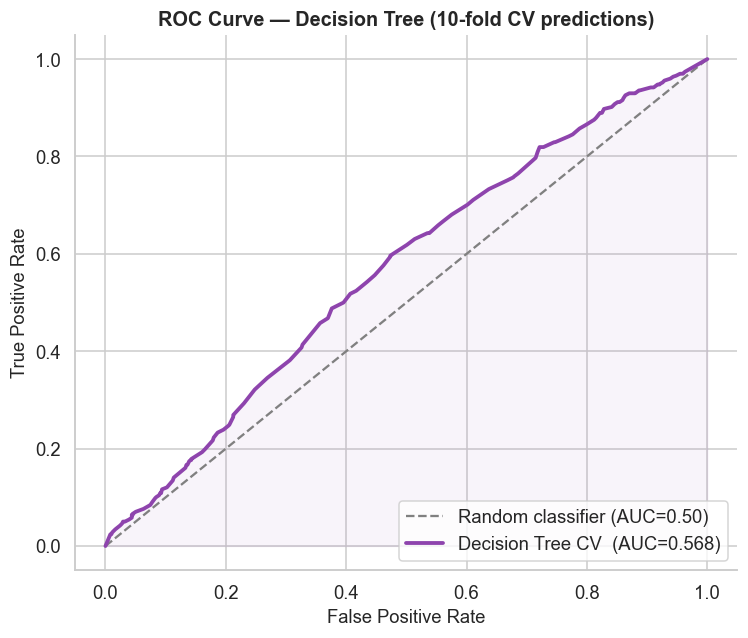

In [29]:
# Step 1: Generate out-of-fold probability predictions via cross-validation
# cross_val_predict ensures unbiased CV estimates (each sample predicted by model not trained on it)
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

dt_pipeline_cv = Pipeline([
    ("pre", simple_pre),                                           # Preprocessing
    ("clf", DecisionTreeClassifier(max_depth=5, random_state=123)) # Decision tree
])

# Get CV probabilities for positive class (method="predict_proba")
y_proba_dt_cv = cross_val_predict(
    dt_pipeline_cv,
    X_train[["metascore", "imdb_rating"]], 
    y_train_enc,
    cv=cv10,              # Same 10-fold CV splits as before
    method="predict_proba", # Return probability estimates (not classes)
    n_jobs=-1             # Parallel processing
)[:, 1]  # Extract positive class probability (2nd column)

# Step 2: Create ROC plot figure
fig, ax = plt.subplots(figsize=(7, 6))

# Step 3: Plot baseline (random classifier diagonal line)
ax.plot([0, 1], [0, 1], "--", color="grey", lw=1.5, label="Random classifier (AUC=0.50)")

# Step 4: CALL YOUR CUSTOM ROC FUNCTION HERE (replaces sklearn's roc_curve + plot)
# Pass: axis object, true labels, predicted probabilities, model name
plot_roc_curve(
    ax=ax,                  # Matplotlib axis to plot on
    y_true=y_train_enc,     # True binary labels from training set
    y_proba=y_proba_dt_cv,  # CV probability predictions
    model_name="Decision Tree CV"  # Label for legend
)

# Step 5: Final formatting
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — Decision Tree (10-fold CV predictions)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")

sns.despine()       # Remove top/right spines (clean look)
plt.tight_layout()
plt.show()


## 9. Build Better Models with Full Feature Set




In [40]:
# =============================================================================
# MODEL ZOO — Complete set of baseline classifiers for model comparison
# =============================================================================

models = {
    # Logistic Regression: Linear model, fast training, interpretable coefficients
    # Good baseline for linearly separable data
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=123),
    
    # Decision Tree: Non-linear, interpretable tree structure, prone to overfitting
    # Visualizable splits make it great for teaching
    "Decision Tree": DecisionTreeClassifier(random_state=123),
    
    # Random Forest: Ensemble of decision trees, reduces overfitting via bagging
    # n_estimators=100 trees, parallelized with n_jobs=-1
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=123, n_jobs=-1),
    
    # XGBoost: Gradient boosting trees, sequential learning, often top performer
    # eval_metric="logloss" for binary classification, verbosity=0 suppresses logs
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=123, verbosity=0),
    
    # LightGBM: Gradient boosting optimized for speed/memory, leaf-wise growth
    # verbose=-1 silences training output, fastest among boosting methods
    "LightGBM": LGBMClassifier(random_state=123, verbose=-1),
    
    # k-NN (k=4): Instance-based learning, distance-weighted nearest neighbors
    # Simple, non-parametric, performs well with proper scaling
    "k-NN (k=4)": KNeighborsClassifier(n_neighbors=4),
}

# Display model overview
print(f"{len(models)} models defined.")
for name in models:
    print(f"  • {name}")


6 models defined.
  • Logistic Regression
  • Decision Tree
  • Random Forest
  • XGBoost
  • LightGBM
  • k-NN (k=4)


### 9.2 Workflows — Bundle Recipe + Model Specification

Each `Pipeline([preprocessor, classifier])` combines a recipe and a model spec.

### 9.3 Cross-Validation Model Comparison



In [41]:
# =============================================================================
# MULTI-METRIC 5-FOLD CV — full feature set + recipe preprocessing
# =============================================================================

# Step 1: Create 5-fold stratified cross-validation splits
# StratifiedKFold: Ensures each fold has SAME class proportions as full dataset
# n_splits=5: Split data into 5 equal parts (80% train, 20% validation per fold)
# shuffle=True: Randomize order before splitting (good practice)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Step 2: Define 5 performance metrics to evaluate each model comprehensively
# Each metric tests different aspect of model performance
scoring_full = {
    "roc_auc":   "roc_auc",        # How well model separates classes (0.5=random, 1.0=perfect)
    "f1":        "f1_weighted",    # Harmonic mean of precision/recall (balanced metric)
    "accuracy":  "accuracy",       # % of correct predictions (can be misleading if imbalanced)
    "precision": "precision_weighted",  # Of predicted positives, what % are actually positive
    "recall":    "recall_weighted",     # Of actual positives, what % did model find
}

# Step 3: Initialize empty list to collect results from all models
results = []

# Step 4: Loop through each model in our "model zoo"
for name, clf in models.items():
    print(f"\nRunning 5-fold CV for: {name}")
    
    # Create pipeline: preprocessing → classifier (like a production-ready system)
    # Ensures SAME preprocessing applied to train AND validation folds
    pipe = Pipeline([
        ("preprocessor", preprocessor),  # Handles missing values, scaling, encoding
        ("classifier", clf)              # Our model (Logistic, Tree, etc.)
    ])
    
    # Use encoded training labels (all models expect 0/1 numeric labels)
    y_cv = y_train_enc   

    # Step 5: Run 5-fold cross-validation with ALL metrics
    # cross_validate trains 5 models, each on 80% of data, validates on 20%
    # Returns dictionary with scores for each metric + training times
    cv_out = cross_validate(
        pipe,                    # Complete pipeline to evaluate
        X_train,                 # Full training feature set
        y_cv,                    # Encoded target labels
        cv=cv5,                  # 5-fold stratified splits
        scoring=scoring_full,    # Calculate all 5 metrics per fold
        n_jobs=-1                # Use all CPU cores for speed
    )

    # Step 6: Store KEY metrics for final summary table
    # .mean() = average across 5 folds, .std() = variability between folds
    results.append({
        "Model":        name,
        "Mean AUC":     cv_out["test_roc_auc"].mean(),           # Primary metric
        "Std AUC":      cv_out["test_roc_auc"].std(),            # Reliability (± variability)
        "Mean F1":      cv_out["test_f1"].mean(),
        "Mean Acc":     cv_out["test_accuracy"].mean(),
        "Fit Time (s)": cv_out["fit_time"].mean(),               # Training speed
    })

    # Step 7: Print progress for each model (live feedback)
    print(f"  {name:25s}  AUC={cv_out['test_roc_auc'].mean():.4f}  "
          f"F1={cv_out['test_f1'].mean():.4f}  "
          f"Acc={cv_out['test_accuracy'].mean():.4f}")

# Step 8: Create final ranked summary table and display
results_df = pd.DataFrame(results).sort_values("Mean AUC", ascending=False)

print("\n" + "="*70)
print(f"{'CROSS-VALIDATION PERFORMANCE SUMMARY':^70}")
print("="*70)
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("="*70)



Running 5-fold CV for: Logistic Regression
  Logistic Regression        AUC=0.6815  F1=0.6337  Acc=0.6359

Running 5-fold CV for: Decision Tree
  Decision Tree              AUC=0.5441  F1=0.5484  Acc=0.5480

Running 5-fold CV for: Random Forest
  Random Forest              AUC=0.6200  F1=0.6004  Acc=0.6054

Running 5-fold CV for: XGBoost
  XGBoost                    AUC=0.6203  F1=0.6011  Acc=0.6045

Running 5-fold CV for: LightGBM
  LightGBM                   AUC=0.6318  F1=0.5975  Acc=0.6000

Running 5-fold CV for: k-NN (k=4)
  k-NN (k=4)                 AUC=0.5888  F1=0.5595  Acc=0.5848

                 CROSS-VALIDATION PERFORMANCE SUMMARY                 
              Model  Mean AUC  Std AUC  Mean F1  Mean Acc  Fit Time (s)
Logistic Regression    0.6815   0.0429   0.6337    0.6359        0.0066
           LightGBM    0.6318   0.0288   0.5975    0.6000        1.7850
            XGBoost    0.6203   0.0358   0.6011    0.6045        0.0222
      Random Forest    0.6200   0.0238   0

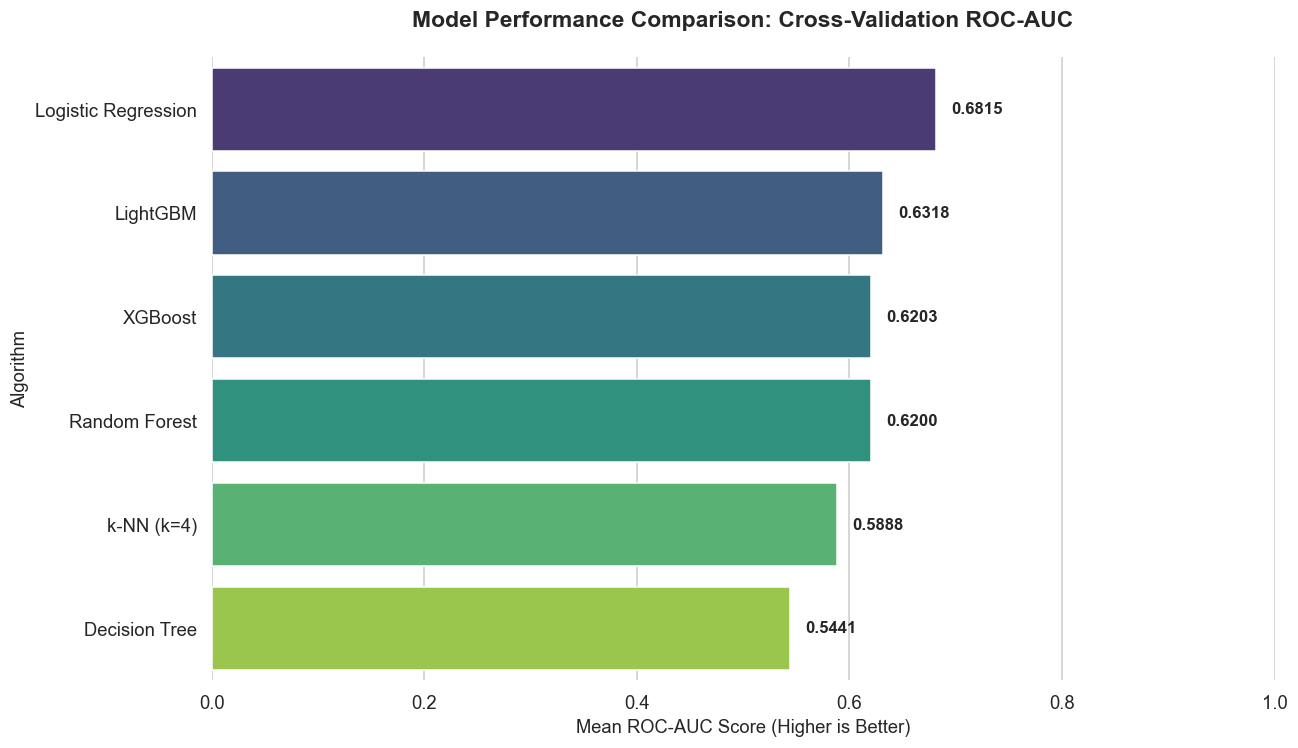

In [42]:
# =============================================================================
# VISUALIZING MODEL COMPARISON (HORIZONTAL BAR CHART)
# =============================================================================

# Step 1: Set clean plotting style with grid (easy to read values)
sns.set_style("whitegrid")

# Step 2: Create wide figure for horizontal bars (model names don't wrap)
fig, ax = plt.subplots(figsize=(12, 7))

# Step 3: Create horizontal bar chart (models on Y-axis, scores on X-axis)
# palette='viridis': Beautiful color gradient (yellow=poor, purple=excellent)
# hue='Model' + dodge=False: Colors bars by model, no side-by-side dodging needed
sns.barplot(
    data=results_df,         # Our CV results DataFrame (already sorted by AUC)
    x='Mean AUC',           # X-axis: performance scores (0-1)
    y='Model',              # Y-axis: model names (automatically ordered by AUC)
    palette='viridis',      # Color gradient: low=light, high=dark
    hue='Model',            # Color each bar by model name
    dodge=False,            # Don't offset bars (we want single bar per model)
    ax=ax                   # Plot on our axis
)

# Step 4: Remove automatic legend (redundant since bars are labeled)
# Safe check prevents errors across Seaborn versions
if ax.get_legend() is not None:
    ax.get_legend().remove()

# Step 5: Professional formatting
ax.set_title('Model Performance Comparison: Cross-Validation ROC-AUC', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Mean ROC-AUC Score (Higher is Better)', fontsize=12)
ax.set_ylabel('Algorithm', fontsize=12)
ax.set_xlim(0, 1.0)  # Fixed 0-1 scale (ROC-AUC range)

# Step 6: Add value labels DIRECTLY ON BARS (most important feature!)
# Seaborn creates "empty" bars due to hue mapping — we filter those out
for container in ax.containers:  # Loop through each set of bars
    # Only label REAL values (>0), leave empty hue placeholders blank
    labels = [f"{v:.4f}" if v > 0 else "" for v in container.datavalues]
    
    ax.bar_label(
        container,           # Bar container to label
        labels=labels,       # Our filtered labels (e.g., "0.8472")
        padding=10,          # Distance from bar edge
        fontsize=11,
        fontweight='bold'    # Stand out against colors
    )

# Step 7: Clean up plot edges (modern look)
sns.despine(left=True, bottom=True)  # Remove left Y-axis and bottom X-axis spines
plt.tight_layout()                   # Optimal spacing
plt.show()


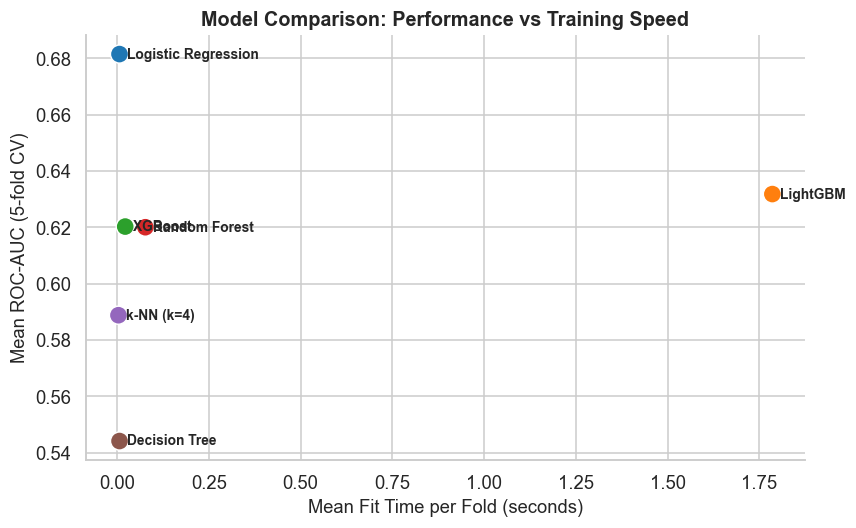

In [43]:
# =============================================================================
# PERFORMANCE vs TRAINING TIME — SCATTERPLOT MODEL COMPARISON
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 5))

# Create scatter: X=fit time, Y=AUC, colored by model
sns.scatterplot(
    data=results_df, 
    x="Fit Time (s)", 
    y="Mean AUC",
    hue="Model", 
    s=140,                    # Dot size
    palette="tab10",          # 10 distinct colors (auto-assigns by Model)
    ax=ax
)

# Add model name labels next to each dot
for _, row in results_df.iterrows():
    ax.annotate(
        row["Model"], 
        xy=(row["Fit Time (s)"], row["Mean AUC"]),
        xytext=(5, 0),           # 5pts right, 0 up
        textcoords="offset points", 
        va="center", fontsize=9,
        fontweight="bold"
    )

# Professional formatting
ax.set_xlabel("Mean Fit Time per Fold (seconds)", fontsize=12)
ax.set_ylabel("Mean ROC-AUC (5-fold CV)", fontsize=12)
ax.set_title("Model Comparison: Performance vs Training Speed", 
             fontsize=13, fontweight="bold")

# Remove legend (labels on dots make it redundant)
ax.get_legend().remove()

sns.despine()
plt.tight_layout()
plt.show()


## 10. Final Model Evaluation on Test Set

We identify the best-performing model from CV, refit on the **full training set**,
then evaluate on the held-out test set exactly once.


In [ ]:
# ── Identify winning model from CV ────────────────────────────────────────
winning_model_name = results_df.iloc[0]["Model"]
winning_clf        = models[winning_model_name]
print(f"Winning model: {winning_model_name} (CV AUC={results_df.iloc[0]['Mean AUC']:.4f})")

# ── Refit on full training set ────────────────────────────────────────────
best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   winning_clf)
])
best_pipeline.fit(X_train, y_train_enc)

# ── Predict on test set ────────────────────────────────────────────────────
y_pred       = best_pipeline.predict(X_test)
y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]

# ── Performance dashboard ──────────────────────────────────────────────────
final_metrics = {
    "Overall Accuracy":     accuracy_score(y_test_enc, y_pred),
    "Precision":            precision_score(y_test_enc, y_pred, pos_label=1),
    "Recall (Sensitivity)": recall_score(y_test_enc, y_pred, pos_label=1),
    "F1-Score":             f1_score(y_test_enc, y_pred, pos_label=1),
    "ROC-AUC Score":        roc_auc_score(y_test_enc, y_pred_proba),
}

print("\n" + "╔" + "═"*58 + "╗")
print(f"║{f' FINAL TEST EVALUATION: {winning_model_name.upper()} ':^58}║")
print("╠" + "═"*58 + "╣")
for metric, value in final_metrics.items():
    print(f"║  {metric:<25} : {value:>28.2%}  ║")
print("╚" + "═"*58 + "╝")

print("\n" + "═"*60)
print(f"{'DETAILED CLASSIFICATION REPORT':^60}")
print("═"*60)
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))


# -------

# =============================================================================
# FINAL EVALUATION ON THE HOLD-OUT TEST SET — ALL TUNED MODELS
# =============================================================================
# Evaluates every tuned model on the held-out test set in CV AUC-ranked order.
# Results are stored in all_results for downstream use (confusion matrices,
# ROC curves, feature importance, SHAP values etc.)
# =============================================================================


# =============================================================================
# EXTRACT & DISPLAY BEST PARAMETERS PER MODEL
# =============================================================================

best_params = {}

for name in grid_objects:
    best_params[name] = grid_objects[name].best_params_
    print(f"\n{name} — Best Parameters:")
    for param, value in grid_objects[name].best_params_.items():
        clean_name = param.replace('classifier__', '')   # strip pipeline prefix
        print(f"  {clean_name:<25}: {value}")

# Access individual model best parameters directly, e.g. for reporting
rf_best_params  = best_params['RandomForest']
xgb_best_params = best_params['XGBoost']
lgbm_best_params = best_params['LightGBM']

all_results = {}

for model_name in tuning_df['Model']:

    # .best_estimator_ is the fully fitted Pipeline using the best hyperparameters found
    pipeline     = grid_objects[model_name].best_estimator_
    y_pred       = pipeline.predict(X_test)
    # predict_proba()[:, 1] gives P(class=1) — the probability of low birthweight
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

    final_metrics = {
        'Accuracy':             accuracy_score(y_test, y_pred),
        'Precision':            precision_score(y_test, y_pred, pos_label=1),
        'Recall (Sensitivity)': recall_score(y_test, y_pred, pos_label=1),
        'F1-Score':             f1_score(y_test, y_pred, pos_label=1),
        'ROC-AUC':              roc_auc_score(y_test, y_pred_proba)
    }

    all_results[model_name] = {
        'pipeline': pipeline,
        'y_pred':   y_pred,
        'y_proba':  y_pred_proba,
        'metrics':  final_metrics
    }

# =============================================================================
# SUMMARY TABLE — ROWS = METRICS, COLUMNS = MODELS
# =============================================================================
# CV time is appended as the final row, sourced from the tuning summary so
# everything is visible in one place for easy comparison.
# =============================================================================

# Build base table: rows = metrics, columns = model names
comparison_df = pd.DataFrame(
    {name: res['metrics'] for name, res in all_results.items()}
)

# Append CV time row from the tuning summary recorded during grid search
cv_times = tuning_df.set_index('Model')['Time Taken (s)'].to_dict()
comparison_df.loc['CV Time (s)'] = {name: cv_times[name] for name in comparison_df.columns}

# Format in place — percentages for metrics, seconds for CV time
display_df = comparison_df.copy()
for idx in display_df.index:
    for col in display_df.columns:
        v = display_df.loc[idx, col]
        display_df.loc[idx, col] = f"{v:.2f}s" if idx == 'CV Time (s)' else f"{v:.1%}"

print("\n" + "="*70)
print(f"{'MODEL COMPARISON — TEST SET PERFORMANCE':^70}")
print("="*70)
print(display_df.to_string())
print("="*70)

# Highlight the best model per metric
print("\nBEST MODEL PER METRIC:")
for metric in comparison_df.index:
    if metric == 'CV Time (s)':
        best = comparison_df.loc[metric].idxmin()
        print(f"  {'Fastest CV':<24}: {best}  ({comparison_df.loc[metric, best]:.2f}s)")
    else:
        best = comparison_df.loc[metric].idxmax()
        print(f"  {metric:<24}: {best}  ({comparison_df.loc[metric, best]:.1%})")

# =============================================================================
# CONFUSION MATRICES — ALL MODELS SIDE BY SIDE
# =============================================================================

fig, axes = plt.subplots(1, len(all_results), figsize=(6 * len(all_results), 5))

if len(all_results) == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, all_results.items()):
    plot_confusion_matrix(ax, y_test, res['y_pred'],
                          title=name, y_proba=res['y_proba'])

plt.suptitle('Confusion Matrices — All Tuned Models (Test Set)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



FINAL TEST PERFORMANCE — ALL MODELS (CV AUC order)
Logistic Regression  → Test ROC-AUC: 65.0%
LightGBM             → Test ROC-AUC: 63.6%
XGBoost              → Test ROC-AUC: 63.4%
Random Forest        → Test ROC-AUC: 64.1%
k-NN (k=4)           → Test ROC-AUC: 61.8%
Decision Tree        → Test ROC-AUC: 53.5%

                    TEST SET SUMMARY — ALL MODELS                     
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC Fit Time (s)
Logistic Regression     0.595      0.558   0.427     0.484    0.650        0.01s
LightGBM                0.599      0.554   0.500     0.525    0.636        1.78s
XGBoost                 0.613      0.571   0.516     0.542    0.634        0.02s
Random Forest           0.606      0.569   0.468     0.513    0.641        0.08s
k-NN (k=4)              0.620      0.641   0.331     0.436    0.618        0.00s
Decision Tree           0.545      0.487   0.444     0.464    0.535        0.01s

🏆 BEST MODEL PER METRIC:
  🥇 Logistic Regression: 

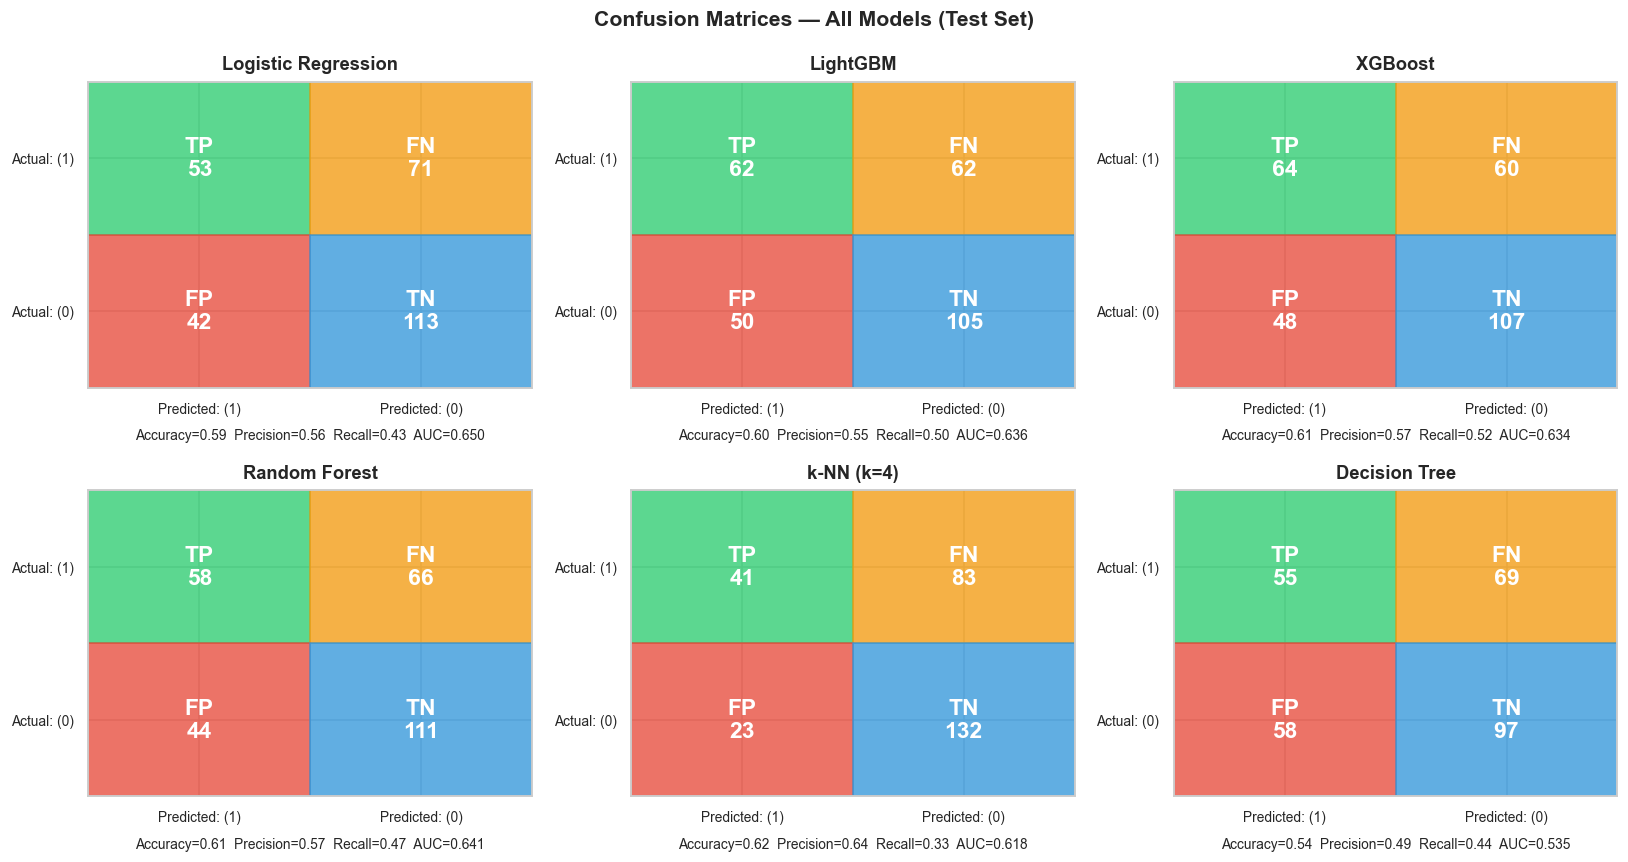

In [48]:
# =============================================================================
# FINAL TEST EVALUATION — ALL MODELS (CV-ranked order)
# =============================================================================

# Step 1: Rank models by CV performance (best first)
results_df_sorted = results_df.sort_values("Mean AUC", ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("FINAL TEST PERFORMANCE — ALL MODELS (CV AUC order)")
print("="*70)

# Step 2: Evaluate EVERY model on held-out test set
all_test_results = {}

for idx, row in results_df_sorted.iterrows():
    model_name = row["Model"]
    clf = models[model_name]  # Get original classifier
    
    # Build + fit pipeline for this model
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])
    pipeline.fit(X_train, y_train_enc)
    
    # Test predictions
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    metrics = {
        "Accuracy":     accuracy_score(y_test_enc, y_pred),
        "Precision":    precision_score(y_test_enc, y_pred, pos_label=1),
        "Recall":       recall_score(y_test_enc, y_pred, pos_label=1),
        "F1-Score":     f1_score(y_test_enc, y_pred, pos_label=1),
        "ROC-AUC":      roc_auc_score(y_test_enc, y_proba),
        "Fit Time (s)": row["Fit Time (s)"]  # From CV
    }
    
    all_test_results[model_name] = {
        'pipeline': pipeline,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'metrics': metrics
    }
    
    # Live progress
    print(f"{model_name:<20} → Test ROC-AUC: {metrics['ROC-AUC']:.1%}")

# Step 3: Create comparison table (Metrics × Models)
comparison_df = pd.DataFrame({name: res['metrics'] for name, res in all_test_results.items()})

# Format display (percentages + seconds)
display_df = comparison_df.round(3).T  # Transpose: Models as rows
display_df['Fit Time (s)'] = display_df['Fit Time (s)'].map(lambda x: f"{x:.2f}s")

print("\n" + "="*70)
print(f"{'TEST SET SUMMARY — ALL MODELS':^70}")
print("="*70)
print(display_df.to_string())
print("="*70)

# Step 4: Best model per metric
print("\n🏆 BEST MODEL PER METRIC:")
for metric in comparison_df.columns:
    if metric == 'Fit Time (s)':
        best_model = comparison_df[metric].idxmin()
        best_val = comparison_df[metric][best_model]
        print(f"  🚀 Fastest: {best_model:<20} ({best_val:.2f}s)")
    else:
        best_model = comparison_df[metric].idxmax()
        best_val = comparison_df[metric][best_model]
        print(f"  🥇 {metric:<12}: {best_model:<20} ({best_val:.1%})")

# Step 5: Confusion matrices for all models
# Step 5: Confusion matrices — MAX 3 PER ROW (auto-wraps perfectly)
n_models = len(all_test_results)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)  # Ensure 2D array format

# Flatten axes for easy iteration (row-major order)
axes_flat = axes.flatten()

model_list = list(all_test_results.items())
for i, (name, res) in enumerate(model_list):
    ax = axes_flat[i]
    plot_confusion_matrix(ax, y_test_enc, res['y_pred'],
                         title=name, y_proba=res['y_proba'])

# Hide unused subplot spaces (if not perfect grid)
for i in range(len(model_list), len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.suptitle('Confusion Matrices — All Models (Test Set)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


Winning model confusion: TN=97, FP=58, FN=69, TP=55


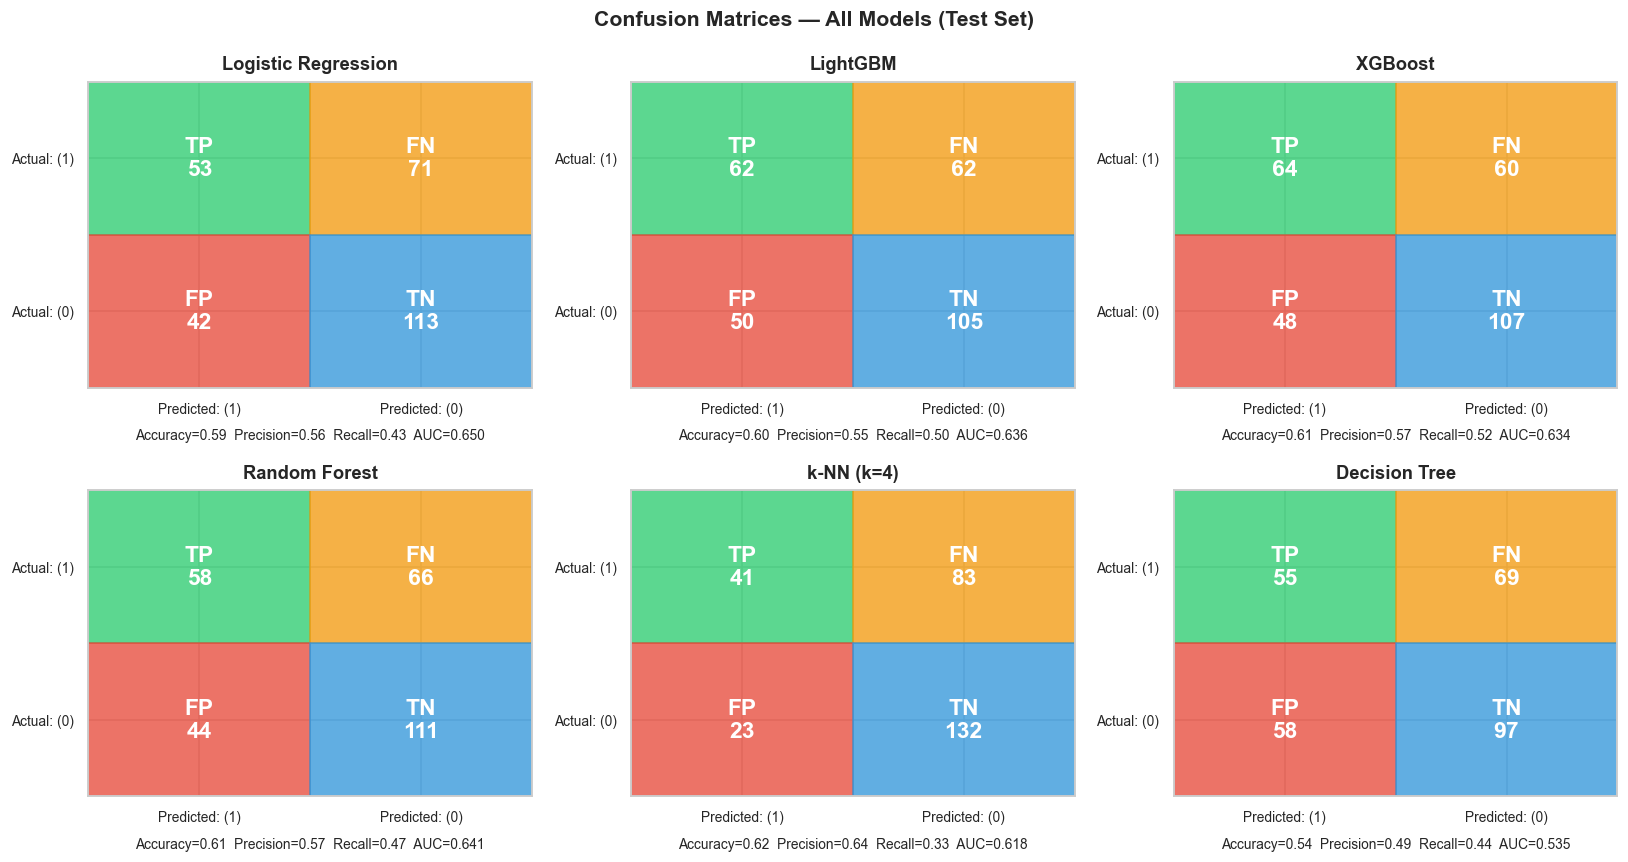

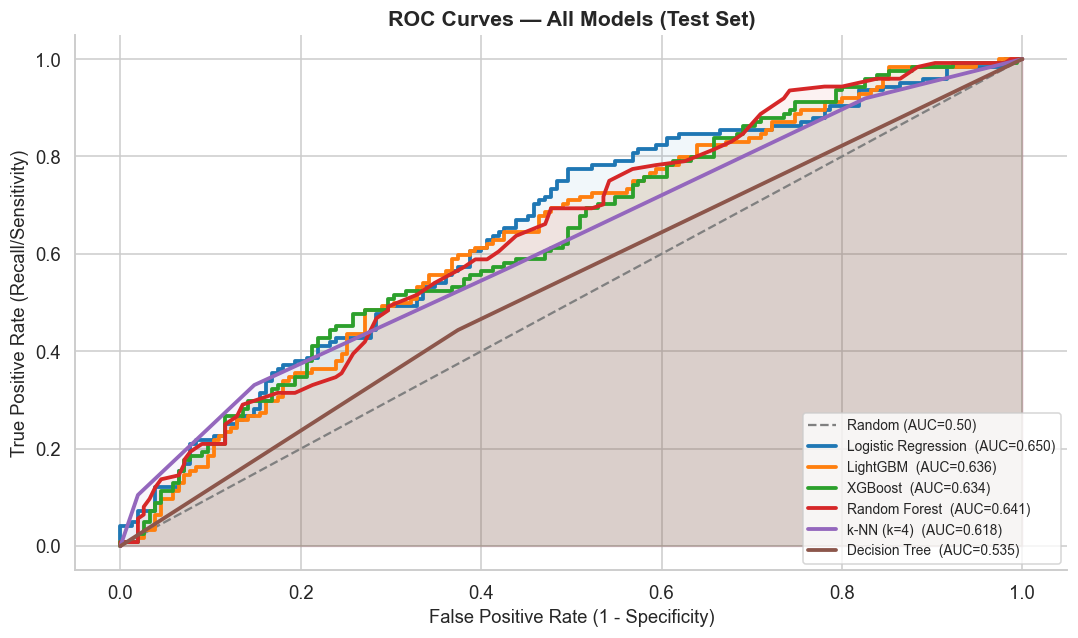

In [51]:
# =============================================================================
# FINAL VISUALIZATION: CONFUSION MATRICES + ROC CURVES FOR ALL MODELS
# =============================================================================

# Step 1: Extract raw confusion matrix values for reference
tn, fp, fn, tp = confusion_matrix(y_test_enc, y_pred).ravel()
print(f"Winning model confusion: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# ────────────────────────────────────────────────────────────────────────────
# CONFUSION MATRICES — 3 PER ROW (ALL MODELS)
# ────────────────────────────────────────────────────────────────────────────
n_models = len(all_test_results)
n_cols = 3  # MAX 3 matrices per row
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

axes_flat = axes.flatten()  # Iterate easily (row 1 col1, row1 col2...)

# Plot confusion matrix for EVERY model
for i, (name, res) in enumerate(all_test_results.items()):
    ax = axes_flat[i]
    plot_confusion_matrix(ax, y_test_enc, res['y_pred'],
                         title=name, y_proba=res['y_proba'])

# Hide empty subplot spaces
for i in range(n_models, len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.suptitle('Confusion Matrices — All Models (Test Set)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────────────────────────────────
# ROC CURVES — ALL MODELS OVERLAY (RAINBOW COMPARISON)
# ────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Baseline lines
ax.plot([0, 1], [0, 1], "--", color="grey", lw=1.5, label="Random (AUC=0.50)")

# Plot ALL models (CV order: best → worst)
model_order = results_df.sort_values("Mean AUC", ascending=False)["Model"]
colors = sns.color_palette("tab10", n_colors=len(model_order))

for i, model_name in enumerate(model_order):
    res = all_test_results[model_name]
    plot_roc_curve(ax, y_test_enc, res['y_proba'], 
                   model_name, color=colors[i])

ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
ax.set_ylabel("True Positive Rate (Recall/Sensitivity)", fontsize=12)
ax.set_title("ROC Curves — All Models (Test Set)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


## 11. Feature Importance


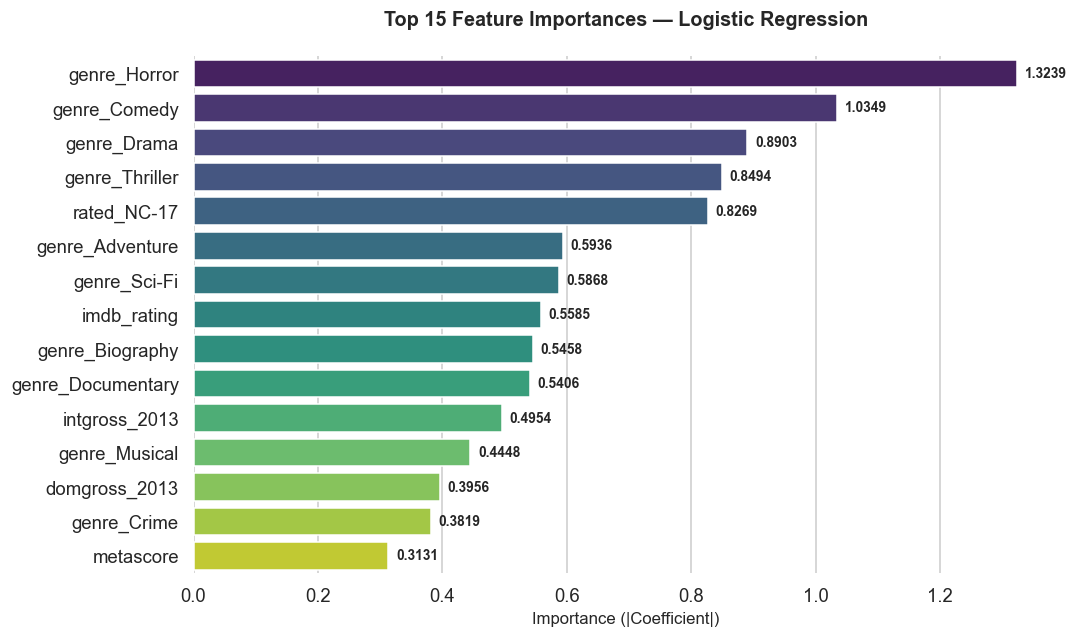

In [53]:
# =============================================================================
# FEATURE IMPORTANCE — What drives the winning model's predictions?
# =============================================================================

# Step 1: EXTRACT TRUE FEATURE NAMES after preprocessing
# Preprocessing transforms raw columns → new columns (OHE expands categories)
fitted_pre = best_pipeline.named_steps["preprocessor"]  # Get fitted preprocessor

try:
    # CATEGORICAL: OneHotEncoder creates new columns like "genre_Action", "rated_R"
    ohe_cats = (fitted_pre.named_transformers_["cat"]         # Categorical pipeline
                           .named_steps["ohe"]               # OneHotEncoder step
                           .get_feature_names_out(categorical_cols))  # Real names!
    
    # NUMERIC: VarianceThreshold might drop columns → get surviving names
    num_out_names = fitted_pre.named_transformers_["num"]["zv"].get_feature_names_out(numeric_cols)
    
    # Combine: ["budget_2013", "metascore", "genre_Action", "rated_R", ...]
    feature_names_out = np.array(list(num_out_names) + list(ohe_cats))
    
except Exception:
    # Fallback: Generic names if above fails (rare)
    feature_names_out = np.array(
        numeric_cols + [f"cat_{i}" for i in range(X_tr_sample.shape[1] - len(numeric_cols))]
    )

# Step 2: EXTRACT MODEL-SPECIFIC IMPORTANCE SCORES
final_clf = best_pipeline.named_steps["classifier"]  # Trained classifier

if hasattr(final_clf, "feature_importances_"):        # Trees (RF, XGB, LGBM)
    importances = final_clf.feature_importances_      # Gini importance (0-1)
    metric_name = "Importance (Gini/Gain)"
    
elif hasattr(final_clf, "coef_"):                     # Logistic Regression
    importances = np.abs(final_clf.coef_[0])          # Absolute coefficient size
    metric_name = "Importance (|Coefficient|)"
    
else:                                                 # kNN, etc. (uniform)
    importances = np.ones(len(feature_names_out))
    metric_name = "Importance"

# Step 3: TIDY + TOP 15 FEATURES
imp_df = (
    pd.DataFrame({
        "Feature": feature_names_out[:len(importances)],  # Match model output length
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)           # Best features first
    .head(15)                                             # Top 15 only
)

# Step 4: PUBLICATION-READY HORIZONTAL BARCHART
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=imp_df, x="Importance", y="Feature",
    palette="viridis",           # Yellow=weak, Purple=strong
    hue="Feature", legend=False, # Color each bar uniquely
    ax=ax
)

# Add values ON bars
for container in ax.containers:
    ax.bar_label(container, 
                fmt="%.4f", padding=5, fontsize=9, fontweight="bold")

ax.set_title(f"Top 15 Feature Importances — {winning_model_name}",
             fontsize=13, fontweight="bold", pad=20)
ax.set_xlabel(metric_name, fontsize=11)
ax.set_ylabel("")  # Feature names already on Y-axis
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


## 13. Conclusion

### Summary

We have successfully:

1. ✅ Loaded and explored the Bechdel Test dataset (1,394 films)
2. ✅ Examined class balance, outliers, correlations, and categorical breakdowns
3. ✅ Split data into 80% train / 20% test (stratified by `test`)
4. ✅ Built a full preprocessing pipeline (rare genre collapse, OHE, standardisation)
5. ✅ Trained initial models on `metascore + imdb_rating` and visualised decision boundaries
6. ✅ Used 10-fold cross-validation to compare simple models
7. ✅ Compared 6 models on the full feature set with 5-fold CV
8. ✅ Evaluated the best model on the held-out test set
9. ✅ Interpreted predictions using feature importance

### Questions to Answer

1. **How many models were specified?** — 6 (Logistic Regression, Decision Tree, Random Forest, XGBoost, LightGBM, k-NN)
2. **What is the difference between a model specification and a workflow?** — A *model specification* defines the algorithm and its hyperparameters. A *workflow* (or `Pipeline` in Python) bundles the preprocessing recipe *and* the model spec into a single object so that data transformations are always applied correctly within each CV fold, preventing leakage.


In [54]:
# Final performance archive
report_data = list(final_metrics.items())
summary_df  = pd.DataFrame(report_data, columns=["Metric", "Score"])

footer = "═" * 60
print("\n" + footer)
print(f"║{f' CHAMPION MODEL: {winning_model_name.upper()} ':^58}║")
print(footer)
for _, row in summary_df.iterrows():
    print(f"║  {row['Metric']:<25} : {row['Score']:>24.2%}  ║")
print(footer)
print(f"║{' Evaluation based on 20% Hold-out Test Set ':^58}║")
print(footer)



════════════════════════════════════════════════════════════
║           CHAMPION MODEL: LOGISTIC REGRESSION            ║
════════════════════════════════════════════════════════════
║  Overall Accuracy          :                   59.50%  ║
║  Precision                 :                   55.79%  ║
║  Recall (Sensitivity)      :                   42.74%  ║
║  F1-Score                  :                   48.40%  ║
║  ROC-AUC Score             :                   65.01%  ║
════════════════════════════════════════════════════════════
║        Evaluation based on 20% Hold-out Test Set         ║
════════════════════════════════════════════════════════════
